# ANÁLISIS COMPLETO PRONACIÓN-SUPINACIÓN — MDS-UPDRS 3.6
## Pipeline: Extracción → Inferencial → Discriminabilidad

**Estructura del pipeline:**
1. Extracción de features (motor de pronación-supinación v2, para todos los scores)
2. Consolidación del dataset con etiquetas de score y sujeto
3. Análisis descriptivo por score
4. Análisis inferencial (Kruskal-Wallis + tamaños de efecto)
5. Análisis de discriminabilidad (LDA + LOSO + AUC/ROC)
6. Exportación de resultados

**Diseño del estudio:**
- Score 0: 23 personas sanas (15 × 6 pruebas + 8 × 4 pruebas = 122 pruebas)
- Scores 1–4: 3 sujetos simulando cada nivel, 10 pruebas c/u (30 pruebas por score)
- Manos: derecha e izquierda (archivos separados por nombre)
- Tarea: Pronación-Supinación MDS-UPDRS ítem 3.6

**Diferencias clínicas vs Finger Tapping:**
- Señal de detección: `gx` (ωx rotacional) **directo**, no el ángulo integrado
- GYRO_LOWCUT = 0.1 Hz (movimiento más lento)
- No se calculan ITI, hesitaciones ni decremento (no aplican a pronación-supinación)
- Amplitud = diferencia pico pronación − pico supinación en ωx
- Cadencia calculada desde picos de pronación reales

**Convención de nombres de archivo esperada:**
```
score0/GA_01_right_01.json  → Score 0, sujeto GA_01, mano derecha, prueba 1
score1/P02_left_05.json     → Score 1, sujeto P02, mano izquierda, prueba 5
```

---
## CELDA 1 — Imports y configuración

In [61]:
"""
============================================================================
IMPORTS Y CONFIGURACIÓN GLOBAL
============================================================================
"""

import json
import os
import re
import warnings
from datetime import datetime
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, find_peaks
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d
from scipy.stats import kruskal, mannwhitneyu, spearmanr

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report,
    matthews_corrcoef
 )
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ─────────────────────────────────────────────
# CONFIGURACIÓN — ajustar rutas aquí
# ─────────────────────────────────────────────
class Config:
    # Raíz del dataset: debe contener subcarpetas score0/, score1/, ..., score4/
    RUTA_DATOS  = "./PRONATION_SUPINATION"   # <── AJUSTAR
    RUTA_SALIDA = "./resultados_pronosupina_completo"

    # ── Señal ──────────────────────────────────────────────────────────
    FS = 100           # Hz objetivo
    FS_TOLERANCE = 0.20

    # ── Filtros (pronación es más lenta → lowcut más bajo que tapping) ──
    GYRO_LOWCUT  = 0.1   # Hz  ← clave: 0.1 en lugar de 0.5 del tapping
    GYRO_HIGHCUT = 10.0  # Hz
    ACCEL_CUTOFF = 5.0   # Hz

    # ── Detección de ciclos ─────────────────────────────────────────────
    # Parámetros originales del notebook Prono-Supina v2
    PICO_PROMINENCE_FACTOR  = 0.15
    PICO_HEIGHT_FACTOR_POS  = 0.15
    PICO_HEIGHT_FACTOR_NEG  = 0.15
    PICO_MIN_DISTANCE       = 15   # muestras (más largo que tapping)
    PICO_WIDTH              = 5
    N_CICLOS_ESPERADOS      = 10
    USAR_TOP_N              = True
    UMBRAL_HESITACION       = 1.5  # intervalo > 1.5 × mediana → hesitación

    # ── Validación ──────────────────────────────────────────────────────
    CICLOS_MIN_VALIDOS = 10   # ← 10 para pronación (vs 6 en tapping)
    DURACION_MINIMA    = 2.0  # segundos

    # ── Scores ──────────────────────────────────────────────────────────
    SCORES = [0, 1, 2, 3, 4]

    # ── Features para análisis ──────────────────────────────────────────
    FEATURES_ANALISIS = [
        'frecuencia', 'cadencia', 'intervalo_medio',
        'intervalo_cv', 'intervalo_std',
        'amplitud_media', 'amplitud_cv', 'amplitud_max',
        'amplitud_angular_media', 'rango_angular_total',
        'velocidad_pico_media', 'velocidad_pico_max',
        'regularidad',
        'n_hesitaciones',
        'decremento_pct', 'decremento_pendiente',
        'compensacion_lateral',
        'jerk_rms', 'jerk_rms_angular',
        'rms_acc_lateral', 'energia_relativa_dom',
        'rango_wx', 'rango_wy', 'rango_wz',
    ]

os.makedirs(Config.RUTA_SALIDA, exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/figuras", exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/tablas", exist_ok=True)

SCORE_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}
SCORE_LABELS = {0:'Score 0\n(Sano)', 1:'Score 1', 2:'Score 2', 3:'Score 3', 4:'Score 4'}

print("✅ Configuración cargada")
print(f"   Ruta datos  : {Config.RUTA_DATOS}")
print(f"   Ruta salida : {Config.RUTA_SALIDA}")
print(f"   GYRO_LOWCUT : {Config.GYRO_LOWCUT} Hz  (pronación-supinación)")
print(f"   Features    : {len(Config.FEATURES_ANALISIS)}")

✅ Configuración cargada
   Ruta datos  : ./PRONATION_SUPINATION
   Ruta salida : ./resultados_pronosupina_completo
   GYRO_LOWCUT : 0.1 Hz  (pronación-supinación)
   Features    : 24


---
## CELDA 2 — Motor de procesamiento de señal (pronación-supinación v2)

In [62]:
"""
============================================================================
MOTOR DE PROCESAMIENTO IMU → FEATURES  —  PRONACIÓN-SUPINACIÓN v2

Diferencias respecto a Finger Tapping:
  • Detección sobre gx (ωx) DIRECTO, no sobre el ángulo integrado
  • GYRO_LOWCUT = 0.1 Hz
  • Umbral fijo PICO_HEIGHT_FACTOR (no adaptativo multi-factor)
  • Rescate selectivo: solo repara el tipo deficiente (pos o neg)
  • Top-N aplicado DESPUÉS de alternancia
  • Cadencia desde picos_pos reales (no desde tiempos_medio)
  • Intervalos, hesitaciones y decremento portados desde FT
  • angulo_x siempre integrado de gx (no del eje dominante)
============================================================================
"""

# ── Filtros ───────────────────────────────────────────────────────────────

def butter_bandpass(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

def butter_lowpass(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff/nyq, btype='low')
    return filtfilt(b, a, data)

# ── Remuestreo ────────────────────────────────────────────────────────────

def eliminar_duplicados_tiempo(time, signals_dict):
    _, idx = np.unique(time, return_index=True)
    idx = np.sort(idx)
    return time[idx], {k: v[idx] for k, v in signals_dict.items()}

def remuestrear_uniforme(time, signals_dict, fs_target):
    time, signals_dict = eliminar_duplicados_tiempo(time, signals_dict)
    if len(time) < 4:
        return None, None
    n = int((time[-1] - time[0]) * fs_target) + 1
    if n < 4:
        return None, None
    t_uni = np.linspace(time[0], time[-1], n)
    return t_uni, {
        k: interp1d(time, v, kind='cubic', fill_value='extrapolate')(t_uni)
        for k, v in signals_dict.items()
    }

# ── Eje dominante ─────────────────────────────────────────────────────────

def detectar_eje_dominante_gyro(gx, gy, gz):
    return max({'gx': np.var(gx), 'gy': np.var(gy), 'gz': np.var(gz)},
               key=lambda k: {'gx': np.var(gx), 'gy': np.var(gy), 'gz': np.var(gz)}[k])

def detectar_eje_dominante_accel(ax, ay, az):
    return max({'ax': np.var(ax), 'ay': np.var(ay), 'az': np.var(az)},
               key=lambda k: {'ax': np.var(ax), 'ay': np.var(ay), 'az': np.var(az)}[k])

# ── Detección de ciclos ───────────────────────────────────────────────────

def seleccionar_top_n_picos(picos_pos, picos_neg, gx_signal, n):
    """[FIX 9] Top-N aplicado DESPUÉS de alternancia."""
    if len(picos_pos) > n:
        idx = np.argsort(np.abs(gx_signal[picos_pos]))[::-1][:n]
        picos_pos = np.sort(picos_pos[idx])
    if len(picos_neg) > n:
        idx = np.argsort(np.abs(gx_signal[picos_neg]))[::-1][:n]
        picos_neg = np.sort(picos_neg[idx])
    return picos_pos, picos_neg

def detectar_ciclos(gx_signal, time_signal, cfg):
    """
    Detección de ciclos de pronación-supinación sobre ωx (gx).
    Orden: Estrategia 1 → Rescate selectivo → Alternancia → Top-N → Emparejamiento
    """
    rango    = np.max(gx_signal) - np.min(gx_signal)
    prom_min = rango * cfg.PICO_PROMINENCE_FACTOR

    # ── Estrategia 1: detección principal ────────────────────────────────
    picos_pos, _ = find_peaks(
        gx_signal,
        prominence=prom_min,
        height=np.max(gx_signal) * cfg.PICO_HEIGHT_FACTOR_POS,
        distance=cfg.PICO_MIN_DISTANCE,
        width=cfg.PICO_WIDTH,
    )
    picos_neg, _ = find_peaks(
        -gx_signal,
        prominence=prom_min,
        # [FIX 11] np.abs → robusto si señal está toda en un lado
        height=np.abs(np.min(gx_signal)) * cfg.PICO_HEIGHT_FACTOR_NEG,
        distance=cfg.PICO_MIN_DISTANCE,
        width=cfg.PICO_WIDTH,
    )

    # ── [FIX 10] Rescate selectivo: SOLO el tipo deficiente ──────────────
    f = 0.5
    if len(picos_pos) < 3:
        p2, _ = find_peaks(
            gx_signal,
            height=np.max(gx_signal) * cfg.PICO_HEIGHT_FACTOR_POS * f,
            prominence=rango * cfg.PICO_PROMINENCE_FACTOR * f,
            distance=cfg.PICO_MIN_DISTANCE,
        )
        if len(p2) > len(picos_pos):
            picos_pos = p2

    if len(picos_neg) < 3:
        n2, _ = find_peaks(
            -gx_signal,
            height=np.abs(np.min(gx_signal)) * cfg.PICO_HEIGHT_FACTOR_NEG * f,
            prominence=rango * cfg.PICO_PROMINENCE_FACTOR * f,
            distance=cfg.PICO_MIN_DISTANCE,
        )
        if len(n2) > len(picos_neg):
            picos_neg = n2

    # ── Alternancia: conservar mayor amplitud absoluta ────────────────────
    todos = sorted(
        [('pos', int(p), gx_signal[p]) for p in picos_pos] +
        [('neg', int(p), gx_signal[p]) for p in picos_neg],
        key=lambda x: x[1],
    )
    fp, fn = [], []
    ut = ui = uv = None
    for tipo, idx, val in todos:
        if ut is None:
            ut, ui, uv = tipo, idx, val
        elif tipo != ut:
            (fp if ut == 'pos' else fn).append(ui)
            ut, ui, uv = tipo, idx, val
        else:
            if abs(val) > abs(uv):
                ui, uv = idx, val
    if ut is not None:
        (fp if ut == 'pos' else fn).append(ui)

    picos_pos = np.array(fp, dtype=int) if fp else np.array([], dtype=int)
    picos_neg = np.array(fn, dtype=int) if fn else np.array([], dtype=int)

    # ── [FIX 9] Top-N DESPUÉS de alternancia ─────────────────────────────
    if cfg.USAR_TOP_N and cfg.N_CICLOS_ESPERADOS > 0:
        picos_pos, picos_neg = seleccionar_top_n_picos(
            picos_pos, picos_neg, gx_signal, cfg.N_CICLOS_ESPERADOS
        )

    # ── Emparejamiento greedy bidireccional ───────────────────────────────
    ciclos = emparejar_ciclos(picos_pos, picos_neg, time_signal, gx_signal)
    return picos_pos, picos_neg, len(ciclos), ciclos


def emparejar_ciclos(picos_pos, picos_neg, time, gx):
    """Greedy bidireccional por mínima distancia temporal."""
    if len(picos_pos) == 0 or len(picos_neg) == 0:
        return []
    pares = sorted(
        [(abs(time[n] - time[p]), int(p), int(n))
         for p in picos_pos for n in picos_neg],
        key=lambda x: x[0],
    )
    ciclos, up, un = [], set(), set()
    for dist, p, n in pares:
        if p not in up and n not in un:
            up.add(p); un.add(n)
            ciclos.append({
                'pos_idx':      p,
                'neg_idx':      n,
                'amplitud':     abs(gx[p] - gx[n]),   # diferencia pron - supina
                'tiempo_medio': (time[p] + time[n]) / 2.0,
                'duracion_ciclo': abs(time[n] - time[p]),
            })
    ciclos.sort(key=lambda x: x['tiempo_medio'])
    return ciclos

# ── Decremento robusto (portado desde Finger Tapping) ─────────────────────

def analizar_decremento(amplitudes, tiempos):
    """
    Regresión lineal sobre amplitudes vs tiempo + comparación entre el
    primer y último tercio. Retorna (slope, r2, dec_pct, hay_dec).
    """
    if len(amplitudes) < 3:
        return 0.0, 0.0, 0.0, False
    amps = np.array(amplitudes); ts = np.array(tiempos)
    z = np.polyfit(ts, amps, 1)
    pred = np.poly1d(z)(ts)
    ss_res = np.sum((amps - pred) ** 2)
    ss_tot = np.sum((amps - np.mean(amps)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    n = len(amps); t = max(1, n // 3)
    ini = np.median(amps[:t]); fin = np.median(amps[-t:])
    dec_pct = ((ini - fin) / ini * 100) if ini > 0 else 0.0
    hay_dec = (dec_pct > 15) and (z[0] < 0) and (r2 > 0.1)
    return float(z[0]), float(r2), float(dec_pct), bool(hay_dec)

# ── Pipeline principal: JSON → features dict ─────────────────────────────

def procesar_json_a_features(json_path, cfg):
    """
    Carga un archivo JSON de IMU y retorna un dict con todas las features
    de pronación-supinación. Retorna None si el archivo es inválido.
    """
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            raw = json.load(f)
    except Exception as e:
        print(f"  ✗ Error cargando {os.path.basename(json_path)}: {e}")
        return None

    # Soporta lista directa o dict con 'imuData'/'data'
    if isinstance(raw, list):
        imu_data = raw
    elif isinstance(raw, dict):
        imu_data = raw.get('imuData', raw.get('data', []))
    else:
        return None

    if len(imu_data) < 50:
        return None

    # Usar el primer dispositivo encontrado
    dispositivos = {}
    for d in imu_data:
        did = d.get('deviceId', 'device0')
        dispositivos.setdefault(did, []).append(d)
    datos = list(dispositivos.values())[0]

    # ── Extraer señales ───────────────────────────────────────────────────
    time = np.array([d['timestamp'] for d in datos])
    time = (time - time[0]) / 1000.0

    sig_raw = {
        'gx': np.array([d.get('gyroscope', {}).get('x', 0) for d in datos]),
        'gy': np.array([d.get('gyroscope', {}).get('y', 0) for d in datos]),
        'gz': np.array([d.get('gyroscope', {}).get('z', 0) for d in datos]),
        'ax': np.array([d.get('accelerometer', {}).get('x', 0) for d in datos]),
        'ay': np.array([d.get('accelerometer', {}).get('y', 0) for d in datos]),
        'az': np.array([d.get('accelerometer', {}).get('z', 0) for d in datos]),
    }

    # ── FS real ──────────────────────────────────────────────────────────
    dt_real = np.median(np.diff(time))
    fs_real = 1.0 / dt_real if dt_real > 0 else cfg.FS

    # ── Remuestreo uniforme ───────────────────────────────────────────────
    time, sig = remuestrear_uniforme(time, sig_raw, fs_real)
    if time is None:
        return None
    dt = 1.0 / fs_real

    # ── Filtros ───────────────────────────────────────────────────────────
    gx_f = butter_bandpass(sig['gx'], cfg.GYRO_LOWCUT, cfg.GYRO_HIGHCUT, fs_real)
    gy_f = butter_bandpass(sig['gy'], cfg.GYRO_LOWCUT, cfg.GYRO_HIGHCUT, fs_real)
    gz_f = butter_bandpass(sig['gz'], cfg.GYRO_LOWCUT, cfg.GYRO_HIGHCUT, fs_real)
    ax_f = butter_lowpass(sig['ax'], cfg.ACCEL_CUTOFF, fs_real)
    ay_f = butter_lowpass(sig['ay'], cfg.ACCEL_CUTOFF, fs_real)
    az_f = butter_lowpass(sig['az'], cfg.ACCEL_CUTOFF, fs_real)

    # ── angulo_x: integración trapezoidal de gx (siempre ωx) ─────────────
    angulo_x = np.insert(np.cumsum(0.5 * (gx_f[:-1] + gx_f[1:])) * dt, 0, 0.0)

    # ── Ejes dominantes ───────────────────────────────────────────────────
    eje_gyro_dom  = detectar_eje_dominante_gyro(gx_f, gy_f, gz_f)
    eje_accel_dom = detectar_eje_dominante_accel(ax_f, ay_f, az_f)

    gyro_map  = {'gx': gx_f, 'gy': gy_f, 'gz': gz_f}
    accel_map = {'ax': ax_f, 'ay': ay_f, 'az': az_f}

    # ── Detección de ciclos sobre gx DIRECTO ─────────────────────────────
    picos_pos, picos_neg, n_ciclos, ciclos = detectar_ciclos(gx_f, time, cfg)

    # ── Features de ciclos ────────────────────────────────────────────────
    amplitudes      = [c['amplitud'] for c in ciclos]
    tiempos_ciclo   = [c['tiempo_medio'] for c in ciclos]
    amp_angulares   = [abs(angulo_x[c['pos_idx']] - angulo_x[c['neg_idx']]) for c in ciclos]
    vel_pico        = ([abs(gx_f[p]) for p in picos_pos] +
                       [abs(gx_f[p]) for p in picos_neg])

    # ── FFT (sobre gx) ────────────────────────────────────────────────────
    N  = len(gx_f)
    yf = fft(gx_f)
    xf = fftfreq(N, 1.0 / fs_real)[:N // 2]
    pw = np.abs(yf[:N // 2])
    freq_dom = float(xf[np.argmax(pw[1:]) + 1]) if len(pw) > 1 else 0.0

    # ── Regularidad de amplitud ───────────────────────────────────────────
    regularidad = 0.0
    if amplitudes and np.mean(amplitudes) > 0:
        cv = np.std(amplitudes) / np.mean(amplitudes)
        regularidad = max(0.0, min(100.0, (1 - cv) * 100))

    # ── [FIX 12] Cadencia desde picos_pos reales (pronación) ─────────────
    # Intervalos pron→pron consecutivos. Mantenemos `intervalo_medio` sobre
    # todos los diffs (compat con cadencia = 1/intervalo_medio).
    diffs = np.array([], dtype=float)
    cadencia = intervalo_real = 0.0
    if len(picos_pos) > 1:
        diffs = np.diff(time[picos_pos])
        intervalo_real = float(np.mean(diffs))
        if intervalo_real > 0:
            cadencia = 1.0 / intervalo_real

    # ── Depuración de intervalos + detección de hesitaciones ─────────────
    # (mismo criterio que Finger Tapping: intervalo > UMBRAL × mediana)
    intervalo_val = []
    hesitaciones  = 0
    if len(diffs) > 0:
        med_it = np.median(diffs)
        intervalo_val = [d for d in diffs if d < med_it * cfg.UMBRAL_HESITACION]
        hesitaciones  = sum(1 for d in diffs if d >= med_it * cfg.UMBRAL_HESITACION)

    intervalo_std = float(np.std(intervalo_val)) if len(intervalo_val) > 0 else 0.0
    intervalo_cv  = (float(np.std(intervalo_val) / np.mean(intervalo_val))
                     if len(intervalo_val) > 0 and np.mean(intervalo_val) > 0
                     else 0.0)

    # ── Decremento de amplitud (portado de FT) ───────────────────────────
    dec_slope, _dec_r2, dec_pct, _hay_dec = analizar_decremento(amplitudes, tiempos_ciclo)

    # ── Compensación lateral: ejes gyro NO dominantes ─────────────────────
    lat_gyro = [v for k, v in gyro_map.items() if k != eje_gyro_dom]
    comp_lat = (float(np.std(np.concatenate([e.reshape(-1) for e in lat_gyro])))
                if lat_gyro else 0.0)

    # ── RMS acc lateral: ejes accel NO dominantes ─────────────────────────
    lat_accel = [v for k, v in accel_map.items() if k != eje_accel_dom]
    rms_acc_lat = (float(np.sqrt(np.mean(np.sum([e**2 for e in lat_accel], axis=0))))
                   if lat_accel else 0.0)

    # ── Jerk (sobre ejes dominantes) ──────────────────────────────────────
    jerk_ang = np.gradient(gx_f, dt)               # jerk angular sobre gx
    jerk_lin = np.gradient(accel_map[eje_accel_dom], dt)  # jerk lineal eje dom

    # ── Energía relativa del eje gyro dominante ───────────────────────────
    e_dom   = float(np.mean(gyro_map[eje_gyro_dom] ** 2))
    e_total = float(np.mean(gx_f**2) + np.mean(gy_f**2) + np.mean(gz_f**2))
    e_rel   = e_dom / e_total if e_total > 0 else 0.0

    # ── Validación ────────────────────────────────────────────────────────
    duracion = float(time[-1] - time[0])
    valido   = (n_ciclos >= cfg.CICLOS_MIN_VALIDOS) and (duracion >= cfg.DURACION_MINIMA)

    return {
        # Metadatos
        'archivo':  os.path.basename(json_path),
        'valido':   valido,
        'n_ciclos': int(n_ciclos),
        'duracion': duracion,
        'fs_real':  float(fs_real),
        'eje_gyro_dom':  eje_gyro_dom,
        'eje_accel_dom': eje_accel_dom,
        # Features
        'frecuencia':             freq_dom,
        'cadencia':               float(cadencia),
        'intervalo_medio':        intervalo_real,
        'intervalo_cv':           intervalo_cv,
        'intervalo_std':          intervalo_std,
        'n_hesitaciones':         int(hesitaciones),
        'decremento_pct':         float(dec_pct),
        'decremento_pendiente':   float(dec_slope),
        'amplitud_media':         float(np.mean(amplitudes)) if amplitudes else 0.0,
        'amplitud_std':           float(np.std(amplitudes))  if amplitudes else 0.0,
        'amplitud_cv':            float(np.std(amplitudes)/np.mean(amplitudes))
                                  if amplitudes and np.mean(amplitudes)>0 else 0.0,
        'amplitud_max':           float(np.max(amplitudes))  if amplitudes else 0.0,
        'amplitud_min':           float(np.min(amplitudes))  if amplitudes else 0.0,
        'amplitud_angular_media': float(np.mean(amp_angulares)) if amp_angulares else 0.0,
        'amplitud_angular_std':   float(np.std(amp_angulares))  if amp_angulares else 0.0,
        'amplitud_angular_max':   float(np.max(amp_angulares))  if amp_angulares else 0.0,
        'rango_angular_total':    float(np.ptp(angulo_x)),
        'velocidad_pico_media':   float(np.mean(vel_pico)) if vel_pico else 0.0,
        'velocidad_pico_max':     float(np.max(vel_pico))  if vel_pico else 0.0,
        'velocidad_pico_std':     float(np.std(vel_pico))  if vel_pico else 0.0,
        'regularidad':            float(regularidad),
        'compensacion_lateral':   float(comp_lat),
        'rango_wx':               float(np.ptp(gx_f)),
        'rango_wy':               float(np.ptp(gy_f)),
        'rango_wz':               float(np.ptp(gz_f)),
        'jerk_rms':               float(np.sqrt(np.mean(jerk_lin**2))),
        'jerk_rms_angular':       float(np.sqrt(np.mean(jerk_ang**2))),
        'rms_acc_lateral':        float(rms_acc_lat),
        'energia_relativa_dom':   float(e_rel),
    }

print("✅ Motor de extracción pronación-supinación listo")

✅ Motor de extracción pronación-supinación listo


---
## CELDA 3 — Carga y consolidación del dataset completo

In [63]:
"""
============================================================================
CARGA DE TODOS LOS ARCHIVOS JSON Y CONSTRUCCIÓN DEL DATAFRAME MAESTRO
============================================================================
"""

def extraer_metadatos(json_data):
    """Extrae sujeto del JSON cargado."""
    # Score ya no lo sacamos de aquí para priorizar la carpeta
    
    # Sujeto
    sujeto = json_data.get('patient', {}).get('id', 'unknown')
    return sujeto


def cargar_dataset_completo(cfg):
    filas = []
    resumen = []
    
    for score in cfg.SCORES:
        carpeta = os.path.join(cfg.RUTA_DATOS, f'Score {score}')
        if not os.path.isdir(carpeta):
            print(f"  ⚠️  Carpeta no encontrada: {carpeta}")
            continue

        archivos = sorted([f for f in os.listdir(carpeta) if f.lower().endswith('.json')])
        ok = invalido = error = 0
        
        for fname in archivos:
            fpath = os.path.join(carpeta, fname)
            
            try:
                with open(fpath, 'r', encoding='utf-8') as f:
                    raw = json.load(f)
            except Exception as e:
                error += 1
                continue
                
            sujeto = extraer_metadatos(raw)
            
            imu_data = raw.get('imuData', raw.get('data', []))
            if not imu_data:
                error += 1
                continue
                
            # Agrupar por deviceId para procesar cada mano
            dispositivos = {}
            for d in imu_data:
                did = d.get('deviceId', 'unknown')
                dispositivos.setdefault(did, []).append(d)
                
            for did, datos in dispositivos.items():
                if 'RIGHT' in did.upper() or 'DERECHA' in did.upper():
                    mano = 'right'
                elif 'LEFT' in did.upper() or 'IZQUIERDA' in did.upper():
                    mano = 'left'
                else:
                    mano = 'unknown'
                    
                # Crear archivo temporal con los datos de esta mano
                # para no alterar procesar_json_a_features
                temp_path = f"temp_imu_{sujeto}_{mano}.json"
                try:
                    with open(temp_path, 'w', encoding='utf-8') as f:
                        json.dump(datos, f)
                    
                    feats = procesar_json_a_features(temp_path, cfg)
                finally:
                    if os.path.exists(temp_path):
                        os.remove(temp_path)
                
                if feats is None:
                    error += 1
                    continue
                    
                feats['score']    = int(score)
                feats['sujeto']   = sujeto
                feats['mano']     = mano
                feats['n_prueba'] = 1  # Ajustar si se cruzan pruebas del mismo sujeto
                
                if feats['valido']:
                    filas.append(feats)
                    ok += 1
                else:
                    invalido += 1
                
        resumen.append({'score': score, 'total': len(archivos),
                        'válidos': ok, 'inválidos': invalido, 'errores': error})
        print(f"  Score {score}: {len(archivos)} archivos → {ok} válidos, {invalido} inválidos, {error} errores")
        
    return pd.DataFrame(filas), pd.DataFrame(resumen)


print("🔄 Cargando dataset...")
df_master, df_resumen_carga = cargar_dataset_completo(Config)

print(f"\n{'='*60}")
print(f"DATASET CARGADO: {len(df_master)} pruebas válidas")
print(f"{'='*60}")
if not df_resumen_carga.empty:
    print(df_resumen_carga.to_string(index=False))
    print(f"\nScores presentes : {sorted(df_master['score'].unique())}")
    print(f"Sujetos únicos   : {df_master['sujeto'].nunique()}")
    print(f"Manos            : {df_master['mano'].unique().tolist()}")
    print(f"Features         : {len(Config.FEATURES_ANALISIS)}")

    print("\nPruebas por score × mano:")
    print(df_master.groupby(['score','mano']).size().unstack(fill_value=0).to_string())

    csv_path = f"{Config.RUTA_SALIDA}/tablas/dataset_maestro.csv"
    df_master.to_csv(csv_path, index=False)
    print(f"\n💾 Dataset guardado: {csv_path}")
else:
    print("⚠️ No se cargaron datos válidos.")

🔄 Cargando dataset...
  Score 0: 102 archivos → 149 válidos, 55 inválidos, 0 errores
  Score 1: 30 archivos → 59 válidos, 1 inválidos, 0 errores
  Score 2: 31 archivos → 61 válidos, 1 inválidos, 0 errores
  Score 3: 31 archivos → 62 válidos, 0 inválidos, 0 errores
  Score 4: 31 archivos → 60 válidos, 2 inválidos, 0 errores

DATASET CARGADO: 391 pruebas válidas
 score  total  válidos  inválidos  errores
     0    102      149         55        0
     1     30       59          1        0
     2     31       61          1        0
     3     31       62          0        0
     4     31       60          2        0

Scores presentes : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Sujetos únicos   : 21
Manos            : ['right', 'left']
Features         : 24

Pruebas por score × mano:
mano   left  right
score             
0        75     74
1        29     30
2        31     30
3        31     31
4        30     30

💾 Dataset guardado: ./resultados_pronosupina_comple

---
## CELDA 4 — Análisis descriptivo por score

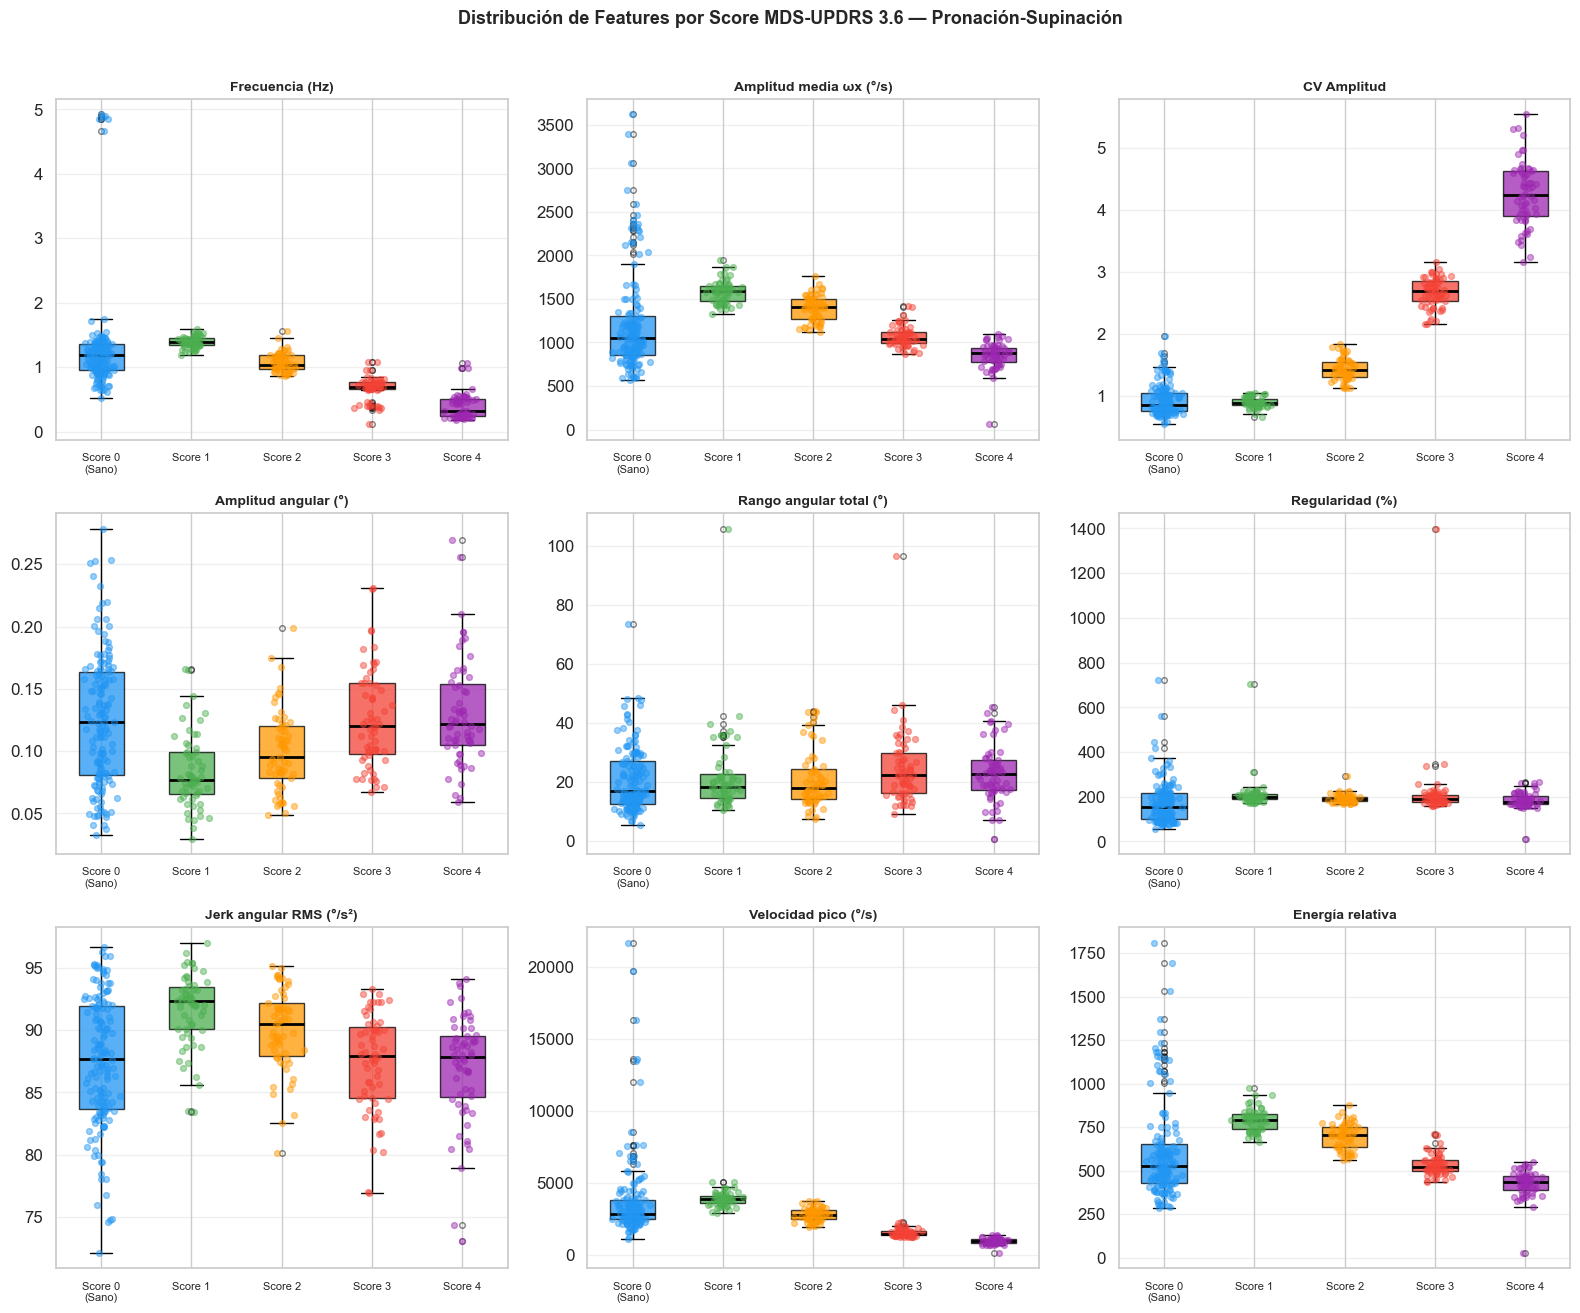

✅ Boxplots guardados

Medianas por score — features principales:
score                    0         1         2         3        4
feature                                                          
amplitud_cv          0.123     0.077     0.095     0.120    0.122
amplitud_media    1053.063  1587.014  1412.576  1040.642  874.598
frecuencia           1.190     1.385     1.040     0.695    0.324
intervalo_medio      0.842     0.885     1.407     2.681    4.244
jerk_rms_angular  2854.335  3882.543  2785.737  1466.405  959.464
regularidad         87.691    92.319    90.454    87.957   87.846


In [64]:
"""
============================================================================
ANÁLISIS DESCRIPTIVO
Features elegidas para visualizar: las más relevantes clínicamente
para pronación-supinación (sin ITI/hesitaciones/decremento)
============================================================================
"""

FEATURES_PLOT = [
    'frecuencia', 'amplitud_media', 'intervalo_medio', 'amplitud_cv',
    'amplitud_angular_media', 'rango_angular_total', 'regularidad',
    'jerk_rms_angular', 'velocidad_pico_media', 'energia_relativa_dom'
]

LABELS_PLOT = [
    'Frecuencia (Hz)', 'Amplitud media ωx (°/s)', 'CV Amplitud',
    'Amplitud angular (°)', 'Rango angular total (°)', 'Regularidad (%)',
    'Jerk angular RMS (°/s²)', 'Velocidad pico (°/s)', 'Energía relativa'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(FEATURES_PLOT, LABELS_PLOT)):
    ax = axes[i]
    data_por_score = [df_master[df_master['score']==s][feat].dropna().values
                      for s in Config.SCORES]

    bp = ax.boxplot(data_por_score,
                    labels=[SCORE_LABELS[s] for s in Config.SCORES],
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))

    for patch, score in zip(bp['boxes'], Config.SCORES):
        patch.set_facecolor(SCORE_COLORS[score])
        patch.set_alpha(0.75)

    for j, (datos, score) in enumerate(zip(data_por_score, Config.SCORES)):
        x = np.random.normal(j+1, 0.07, size=len(datos))
        ax.scatter(x, datos, alpha=0.45, s=18, color=SCORE_COLORS[score], zorder=5)

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribución de Features por Score MDS-UPDRS 3.6 — Pronación-Supinación',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/descriptivo_boxplots.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Boxplots guardados")

# ── Tabla de estadísticos por score ──
rows = []
for score in Config.SCORES:
    sub = df_master[df_master['score']==score]
    for feat in Config.FEATURES_ANALISIS:
        v = sub[feat].dropna()
        rows.append({
            'score': score, 'feature': feat, 'n': len(v),
            'mediana': np.median(v) if len(v)>0 else np.nan,
            'IQR':     np.percentile(v,75)-np.percentile(v,25) if len(v)>0 else np.nan,
            'media':   np.mean(v) if len(v)>0 else np.nan,
            'std':     np.std(v)  if len(v)>0 else np.nan,
        })

df_descriptivo = pd.DataFrame(rows)
df_descriptivo.to_csv(f"{Config.RUTA_SALIDA}/tablas/descriptivo_por_score.csv", index=False)

print("\nMedianas por score — features principales:")
pivot = df_descriptivo[df_descriptivo['feature'].isin(
    ['frecuencia','amplitud_media','intervalo_medio','amplitud_cv','regularidad','jerk_rms_angular']
)].pivot_table(index='feature', columns='score', values='mediana', aggfunc='first').round(3)
print(pivot.to_string())

---
## CELDA 4B — Análisis visual por estadio

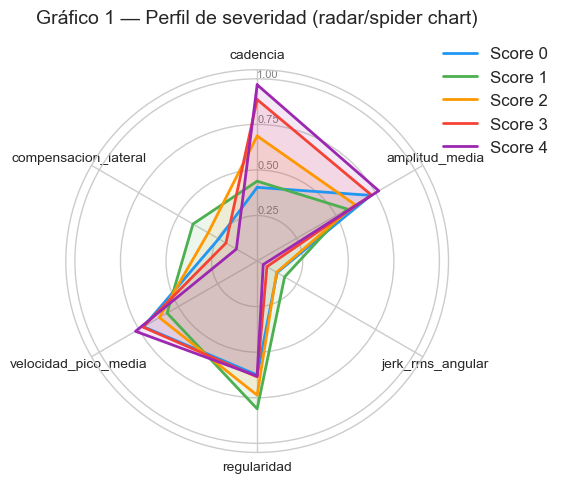

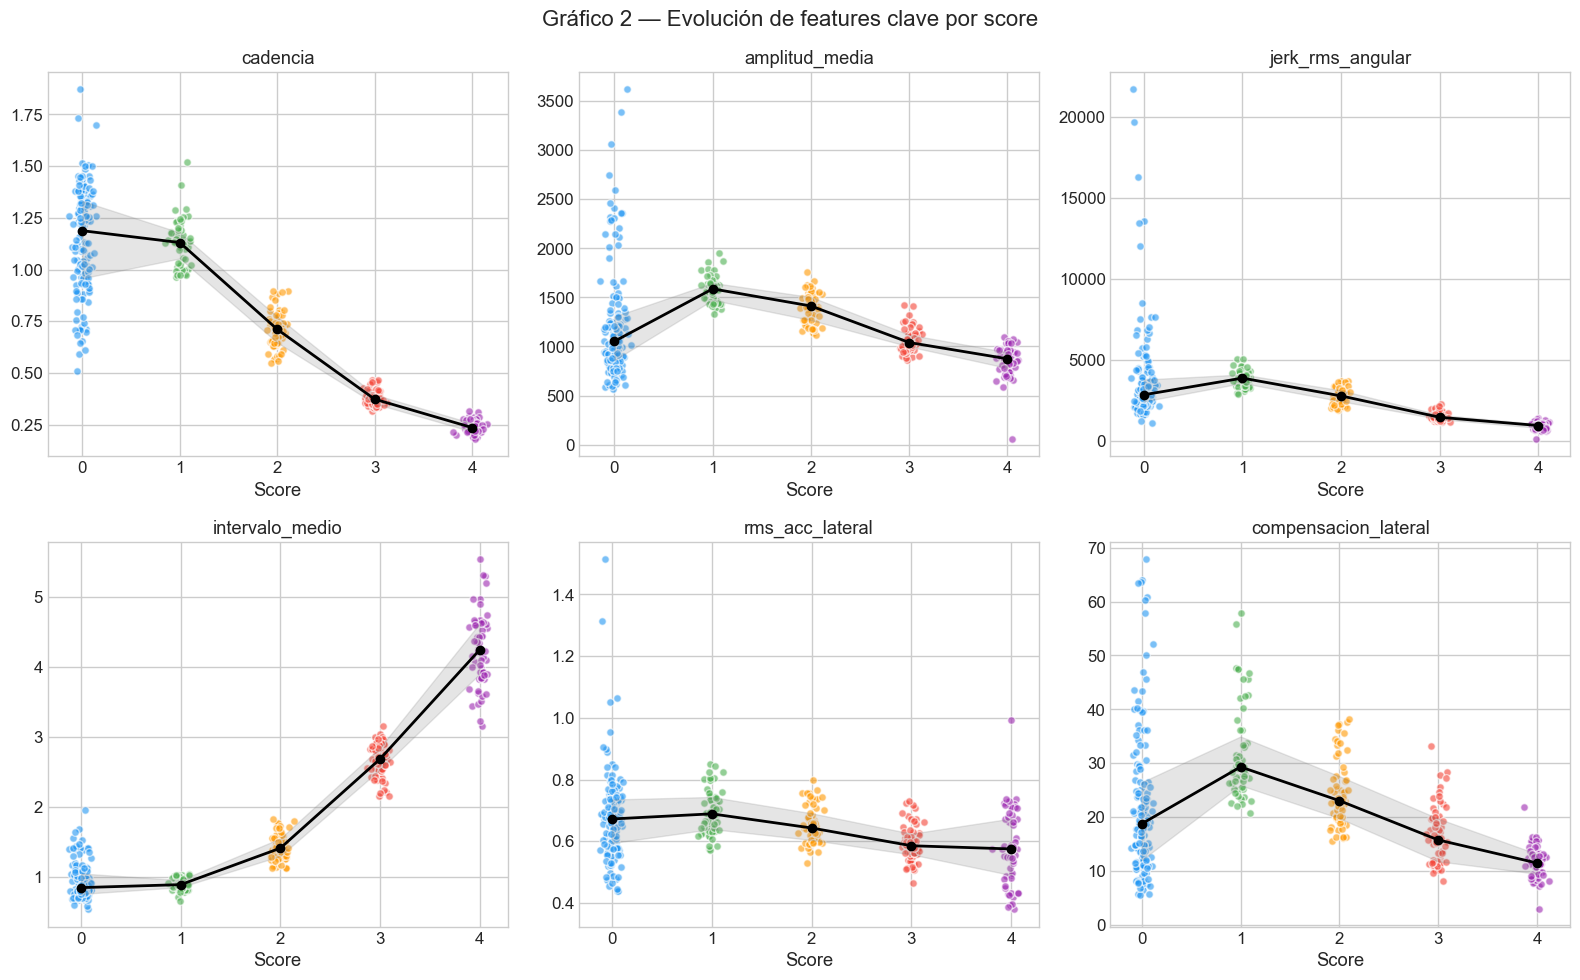

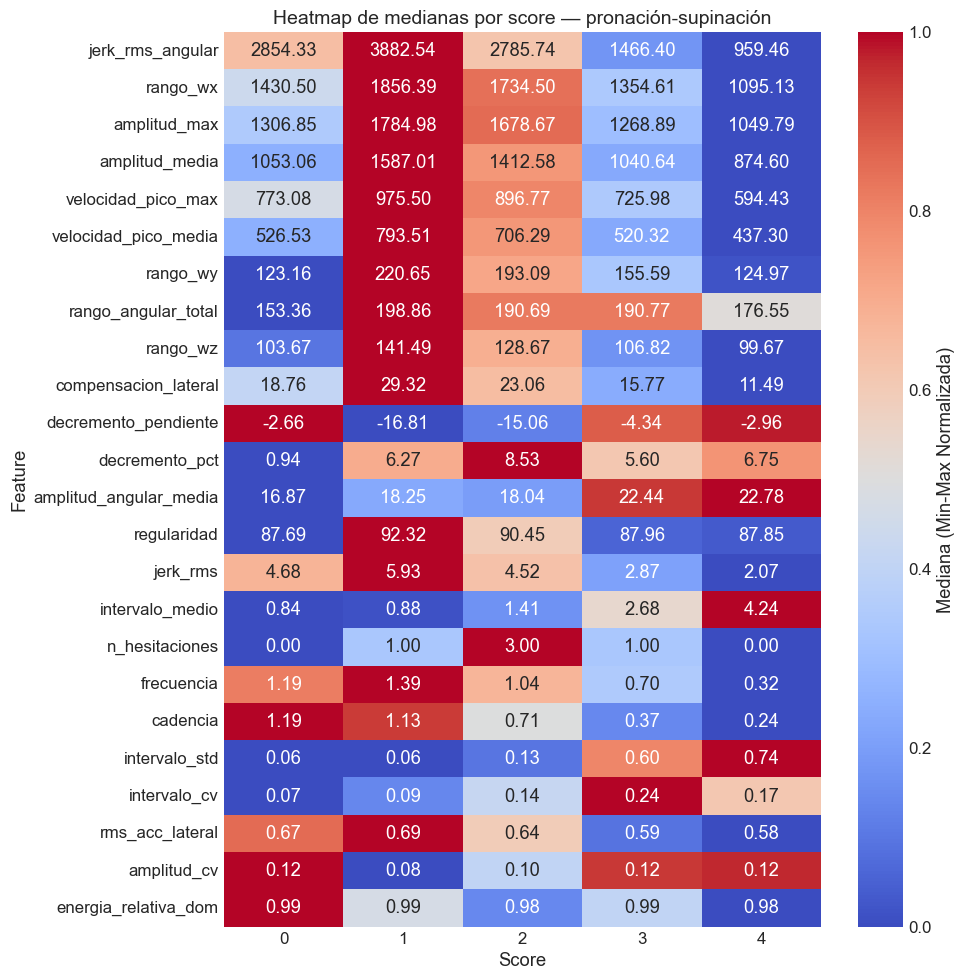

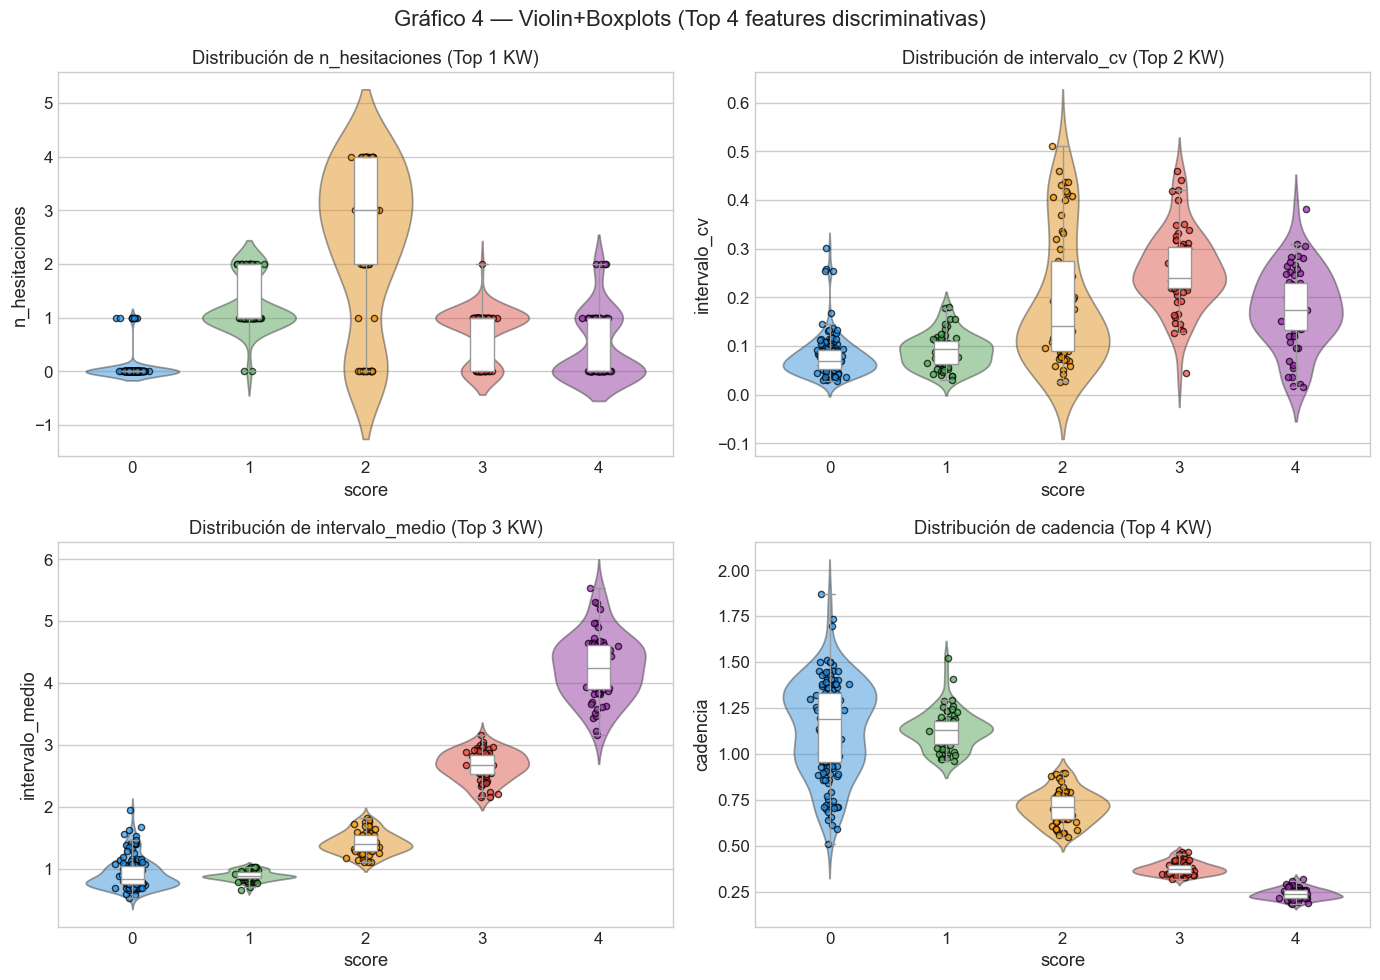

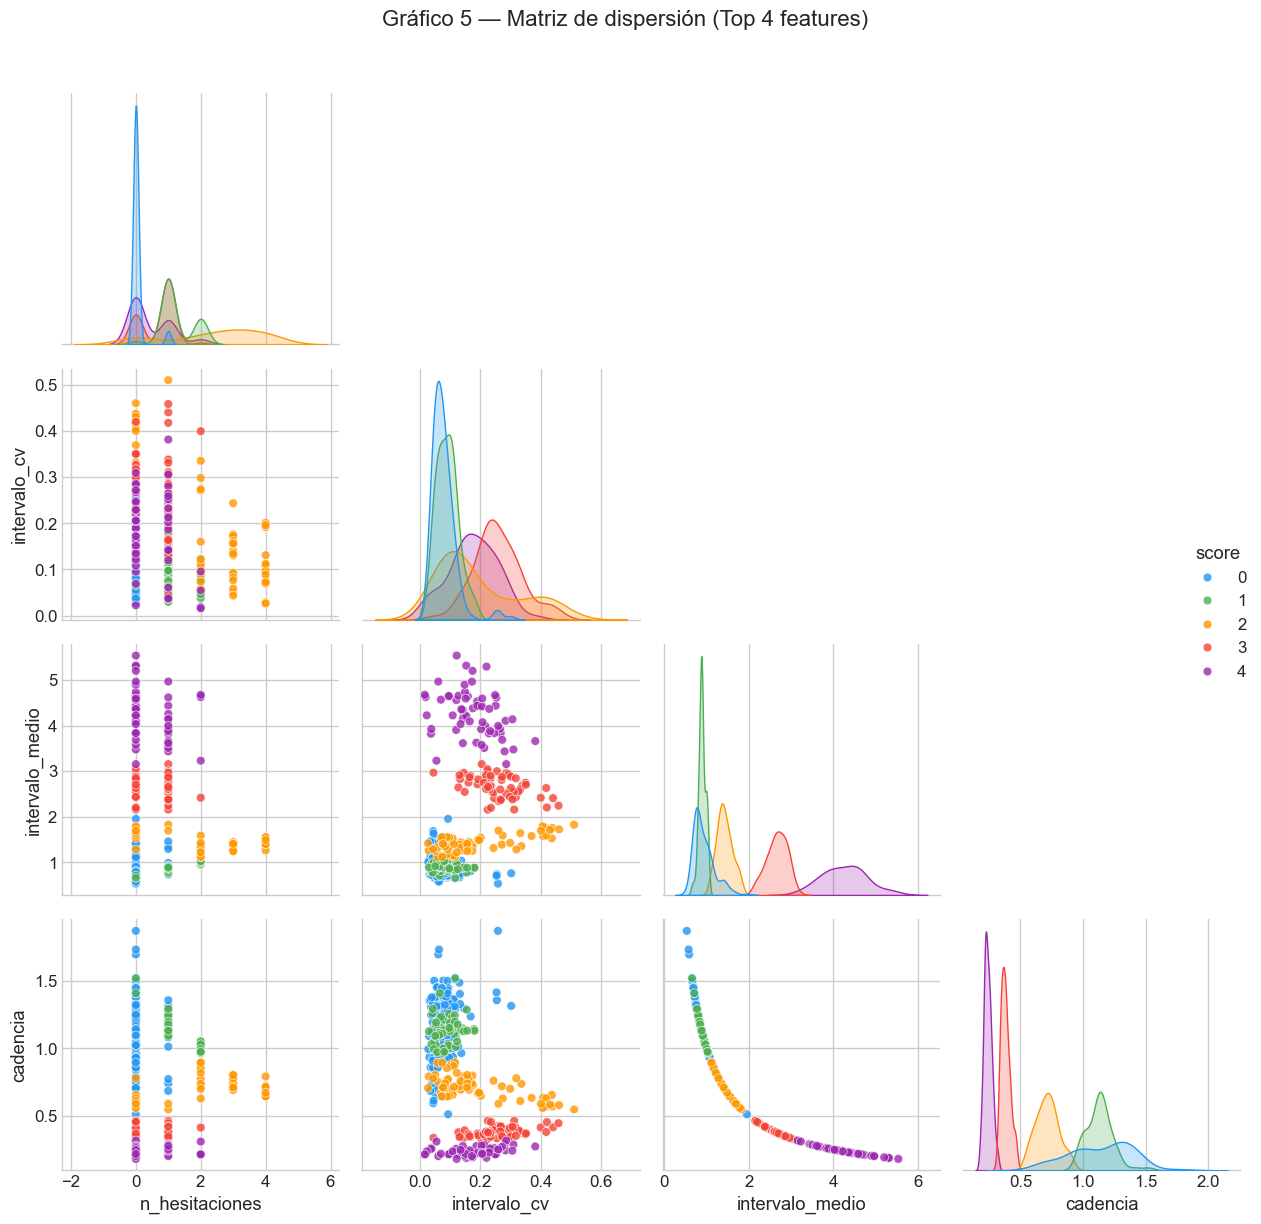

In [65]:
"""
============================================================================
ANÁLISIS VÍSUAL POR ESTADIO
Incluye Radar charts, Evolución de features, Heatmaps, Violin plots y Scatter.
============================================================================
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import kruskal

plt.style.use('seaborn-v0_8-whitegrid')

# Configuración y colores
SCORE_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}
# Agregar versiones en string para compatibilidad con seaborn categórico
SCORE_COLORS.update({str(k): v for k, v in SCORE_COLORS.items()})
SCORE_LABELS = {s: f"Score {s}" for s in Config.SCORES}

# ---------------------------------------------------------
# GRÁFICO 1: Perfil de severidad (radar chart)
# ---------------------------------------------------------
features_radar = ['cadencia', 'amplitud_media', 'jerk_rms_angular', 'regularidad', 'velocidad_pico_media', 'compensacion_lateral']
inv_feats = ['cadencia', 'amplitud_media', 'velocidad_pico_media']

df_radar = df_master[features_radar + ['score']].copy()
scaler = MinMaxScaler()

for f in features_radar:
    # Invertir cadencia, amplitud y velocidad antes de normalizar
    if f in inv_feats:
        df_radar[f] = -df_radar[f]
    df_radar[f] = scaler.fit_transform(df_radar[[f]])

radar_medians = df_radar.groupby('score')[features_radar].median()

N = len(features_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig1, ax1 = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)

plt.xticks(angles[:-1], features_radar, size=10)
ax1.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75, 1.0], ["0.25", "0.50", "0.75", "1.00"], color="grey", size=8)
plt.ylim(0, 1.05)

for score in Config.SCORES:
    values = radar_medians.loc[score].values.flatten().tolist()
    values += values[:1]
    color = SCORE_COLORS[score]
    ax1.plot(angles, values, linewidth=2, linestyle='solid', label=f'Score {score}', color=color)
    ax1.fill(angles, values, color=color, alpha=0.1)

plt.title('Gráfico 1 — Perfil de severidad (radar/spider chart)', size=14, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
fig1.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_radar.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 2: Evolución de features clave por score
# ---------------------------------------------------------
features_evol = ['cadencia', 'amplitud_media', 'jerk_rms_angular', 'intervalo_medio', 'rms_acc_lateral', 'compensacion_lateral']
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 10))
axes2 = axes2.flatten()

for i, feat in enumerate(features_evol):
    ax = axes2[i]
    medians, p25, p75 = [], [], []
    for s in Config.SCORES:
        val = df_master[df_master['score'] == s][feat].dropna()
        medians.append(val.median() if len(val)>0 else np.nan)
        p25.append(val.quantile(0.25) if len(val)>0 else np.nan)
        p75.append(val.quantile(0.75) if len(val)>0 else np.nan)
        
        # Scatter + Jitter
        x_jitter = np.random.normal(s, 0.05, size=len(val))
        ax.scatter(x_jitter, val, color=SCORE_COLORS[s], alpha=0.6, s=30, edgecolor='white')
        
    ax.plot(Config.SCORES, medians, color='black', linewidth=2, marker='o', markersize=6)
    ax.fill_between(Config.SCORES, p25, p75, color='gray', alpha=0.2)
    
    ax.set_title(feat)
    ax.set_xlabel('Score')
    ax.set_xticks(Config.SCORES)

fig2.suptitle('Gráfico 2 — Evolución de features clave por score', fontsize=16)
plt.tight_layout()
fig2.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_evolucion_features.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 3: Heatmap de medianas (Min-max normalizado)
# ---------------------------------------------------------
heatmap_data = df_master.groupby('score')[Config.FEATURES_ANALISIS].median().T
heatmap_range = heatmap_data.max(axis=1) - heatmap_data.min(axis=1)
heatmap_norm = heatmap_data.apply(lambda row: (row - row.min()) / (row.max() - row.min()) if row.max() != row.min() else row, axis=1)

sorted_idx = heatmap_range.sort_values(ascending=False).index
heatmap_data_sorted = heatmap_data.loc[sorted_idx]
heatmap_norm_sorted = heatmap_norm.loc[sorted_idx]

fig3, ax3 = plt.subplots(figsize=(10, 10))
sns.heatmap(heatmap_norm_sorted, annot=heatmap_data_sorted, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Mediana (Min-Max Normalizada)'}, ax=ax3)
ax3.set_title("Heatmap de medianas por score — pronación-supinación", fontsize=14)
ax3.set_xlabel("Score")
ax3.set_ylabel("Feature")
plt.tight_layout()
fig3.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_heatmap_medianas.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 4: Violin plot combinado para las top 4 features
# ---------------------------------------------------------
# Si df_kw existe, filtrar features que aún existen en df_master
if 'df_kw' in locals():
    top_4 = [f for f in df_kw['feature'].tolist() if f in df_master.columns][:4]
else:
    top_4 = []

# Si no hay suficientes features válidas, recalcular desde cero
if len(top_4) < 4:
    _df_kw = df_agregado if 'df_agregado' in locals() else df_master
    def _calc_h(feat):
        g = [_df_kw[_df_kw['score']==s][feat].dropna().values for s in Config.SCORES]
        g = [x for x in g if len(x) >= 2]
        return kruskal(*g)[0] if len(g)>1 else 0
    _all = pd.Series({f: _calc_h(f) for f in Config.FEATURES_ANALISIS if f in df_master.columns}).sort_values(ascending=False)
    _existing = set(top_4)
    for feat in _all.index:
        if feat not in _existing:
            top_4.append(feat)
        if len(top_4) >= 4:
            break
    top_4 = top_4[:4]
fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))
axes4 = axes4.flatten()

for i, feat in enumerate(top_4):
    ax = axes4[i]
    sns.violinplot(data=df_master, x='score', y=feat, ax=ax, palette=SCORE_COLORS, inner=None, alpha=0.5)
    sns.boxplot(data=df_master, x='score', y=feat, ax=ax, width=0.2, color='white', fliersize=0)
    
    # Scatter + Jitter
    for s in Config.SCORES:
        val = df_master[df_master['score'] == s][feat].dropna()
        x_jitter = np.random.normal(s, 0.05, size=len(val))
        ax.scatter(x_jitter, val, color=SCORE_COLORS[s], edgecolor='black', alpha=0.7, s=20)
        
    ax.set_title(f"Distribución de {feat} (Top {i+1} KW)")

fig4.suptitle('Gráfico 4 — Violin+Boxplots (Top 4 features discriminativas)', fontsize=16)
plt.tight_layout()
fig4.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_violins_top4.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 5: Matriz de dispersión (Scatter Matrix) de las top 4
# ---------------------------------------------------------
df_scatter = df_master[top_4 + ['score']].dropna()
fig5 = sns.pairplot(df_scatter, hue='score', palette=SCORE_COLORS, height=3, corner=True,
                    plot_kws={'alpha':0.8, 's':40, 'edgecolor':'w'}, diag_kws={'common_norm':False})

fig5.fig.suptitle('Gráfico 5 — Matriz de dispersión (Top 4 features)', y=1.02, fontsize=16)
plt.tight_layout()
fig5.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_scatter_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

---
## CELDA 5 — Análisis inferencial: Kruskal-Wallis + tamaños de efecto

In [66]:
"""
============================================================================
ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS

Para cada feature:
  - Kruskal-Wallis H (5 grupos: scores 0–4)
  - p-valor con corrección Bonferroni
  - Eta² (tamaño de efecto)

CORRECCIÓN: el KW corre sobre df_agregado (mediana por sujeto-score)
para no inflar artificialmente el N con múltiples pruebas por sujeto.
N real = sujetos independientes: Score0≈23, Scores1-4=3 c/u.
============================================================================
"""

# ── Agregación por sujeto-score (mediana) para no inflar N artificialmente
df_agregado = (
    df_master
    .groupby(['sujeto', 'score'])[Config.FEATURES_ANALISIS]
    .median()
    .reset_index()
)

print("Agregación por sujeto-score (mediana):")
print(df_agregado.groupby('score')['sujeto'].nunique())
print(f"Total sujetos independientes: {df_agregado['sujeto'].nunique()}")
print(f"N por score: {df_agregado.groupby('score').size().to_dict()}")
print()


def eta_cuadrado(H, k, n):
    val = (H - k + 1) / (n - k) if (n - k) > 0 else 0.0
    return max(0.0, val)

def interpretar_eta(eta2):
    if eta2 < 0.01:
        return 'ninguno'
    if eta2 < 0.06:
        return 'pequeño'
    if eta2 < 0.14:
        return 'medio'
    return 'grande'


alpha = 0.05
n_features = len(Config.FEATURES_ANALISIS)
alpha_bonf = alpha / n_features

print("=" * 70)
print("ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS (5 grupos: Score 0–4)")
print(f"NOTA: Scores 1-4 tienen N=3 sujetos → poder estadístico bajo (~25%)")
print(f"      El análisis es metodológicamente obligatorio pero complementario.")
print(f"      KW corre sobre MEDIANA POR SUJETO (N independiente, no N de pruebas)")
print("=" * 70)

resultados_kw = []
for feat in Config.FEATURES_ANALISIS:
    grupos = [df_agregado[df_agregado['score'] == s][feat].dropna().values
              for s in Config.SCORES]
    grupos_v = [g for g in grupos if len(g) >= 2]
    if len(grupos_v) < 2:
        continue
    try:
        H, p = kruskal(*grupos_v)
    except Exception:
        continue
    n_total = sum(len(g) for g in grupos_v)
    k = len(grupos_v)
    eta2 = eta_cuadrado(H, k, n_total)
    resultados_kw.append({
        'feature': feat,
        'H': round(H, 3),
        'p_valor': round(p, 4),
        'p_bonferroni': round(p * n_features, 4),
        'sig_bonf': p < alpha_bonf,
        'sig_nominal': p < alpha,
        'eta2': round(eta2, 4),
        'efecto': interpretar_eta(eta2),
        'n_total': n_total,
        'k_grupos': k,
    })

df_kw = pd.DataFrame(resultados_kw).sort_values('eta2', ascending=False)

print(f"\n{'Feature':<28} {'H':>7} {'p':>8} {'p×Bonf':>9} {'Sig?':>5} {'Eta²':>7} {'Efecto'}")
print("-" * 70)
for _, row in df_kw.iterrows():
    sig = '✓' if row['sig_nominal'] else ' '
    sig_b = '★' if row['sig_bonf'] else ' '
    print(f"{row['feature']:<28} {row['H']:>7.2f} {row['p_valor']:>8.4f} "
          f"{min(row['p_bonferroni'], 1.0):>9.4f} {sig + sig_b:>5} "
          f"{row['eta2']:>7.4f} {row['efecto']}")

print(f"\n✓ = p<0.05 nominal  |  ★ = p<0.05 Bonferroni ({alpha_bonf:.4f})")
print("Eta² interpretación: <0.01 ninguno | 0.01-0.06 pequeño | 0.06-0.14 medio | >0.14 grande")

df_kw.to_csv(f"{Config.RUTA_SALIDA}/tablas/kruskal_wallis.csv", index=False)
print(f"\n💾 Resultados KW guardados")


Agregación por sujeto-score (mediana):
score
0    20
1     3
2     3
3     3
4     3
Name: sujeto, dtype: int64
Total sujetos independientes: 21
N por score: {0: 20, 1: 3, 2: 3, 3: 3, 4: 3}

ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS (5 grupos: Score 0–4)
NOTA: Scores 1-4 tienen N=3 sujetos → poder estadístico bajo (~25%)
      El análisis es metodológicamente obligatorio pero complementario.
      KW corre sobre MEDIANA POR SUJETO (N independiente, no N de pruebas)

Feature                            H        p    p×Bonf  Sig?    Eta² Efecto
----------------------------------------------------------------------
n_hesitaciones                 30.97   0.0000    0.0001    ✓★  0.9990 grande
intervalo_cv                   19.46   0.0006    0.0153    ✓★  0.5728 grande
intervalo_medio                19.00   0.0008    0.0188    ✓★  0.5556 grande
cadencia                       19.00   0.0008    0.0188    ✓★  0.5556 grande
intervalo_std                  18.81   0.0009    0.0205    ✓★  0.5485 grande


---
## CELDA 6 — Análisis de discriminabilidad: LDA + LOSO

In [67]:
"""
============================================================================
ANÁLISIS DE DISCRIMINABILIDAD — LDA CON LEAVE-ONE-SUBJECT-OUT (LOSO)

Validación: LeaveOneGroupOut por sujeto.
Con 3 sujetos en scores 1-4 → 3 folds por score.
Score 0 con 23 sujetos → se usa como base amplia de normalidad.

Clasificador principal: LDA con shrinkage automático.
Alternativa: SVM lineal.
============================================================================
"""

df_model = df_master[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
df_model['score'] = df_model['score'].astype(int)
df_model['grupo_loso'] = df_model['sujeto']

print(f"Dataset para clasificación: {len(df_model)} pruebas")
print(df_model.groupby(['score','grupo_loso']).size().to_string())

X      = df_model[Config.FEATURES_ANALISIS].values
y      = df_model['score'].values
grupos = df_model['grupo_loso'].values


def evaluar_loso(X, y, grupos, clf_name='LDA'):
    if clf_name == 'LDA':
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95, n_components=None))
        ])
    else:
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='linear', C=1.0, probability=True))
        ])

    loso = LeaveOneGroupOut()
    y_true_all = []; y_pred_all = []; y_proba_all = []

    for train_idx, test_idx in loso.split(X, y, grupos):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if len(np.unique(y_tr)) < 2:
            continue
        try:
            clf.fit(X_tr, y_tr)
            y_true_all.extend(y_te)
            y_pred_all.extend(clf.predict(X_te))
            y_proba_all.extend(clf.predict_proba(X_te))
        except Exception as e:
            print(f"  ⚠️  Error en fold: {e}")
            continue

    clases = (clf.named_steps['clf'].classes_
              if hasattr(clf.named_steps.get('clf'), 'classes_')
              else np.unique(y))
    calcular_metricas._last_clases = clases
    return (np.array(y_true_all), np.array(y_pred_all),
            np.array(y_proba_all), clases)


print("\n🔄 Ejecutando LDA con LOSO...")
y_true, y_pred, y_proba, clases = evaluar_loso(X, y, grupos, 'LDA')

if len(y_true) == 0:
    print("⚠️  Sin predicciones. Revisar datos.")
else:
    print(f"   Predicciones: {len(y_true)}")
    print("\n" + "="*50)
    print("REPORTE DE CLASIFICACIÓN — LDA LOSO")
    print("="*50)
    print(classification_report(
        y_true, y_pred,
        target_names=[f'Score {s}' for s in sorted(np.unique(y_true))],
        zero_division=0
    ))
    mcc = matthews_corrcoef(y_true, y_pred)


Dataset para clasificación: 391 pruebas
score  grupo_loso
0      1061816906     8
       1080040897    10
       1083875215     8
       1085297617     8
       1105365168     6
       1107836326     7
       1107840162     9
       1112038562     6
       1114240383     8
       1114541823     7
       1116070738    12
       1125288150     7
       1126844663     4
       1144025261     8
       118515383      2
       38603564       7
       59817289       8
       6097302        8
       67007062       8
       94419403       8
1      1084896570    20
       1105365168    20
       1126844663    19
2      1084896570    20
       1105365168    21
       1126844663    20
3      1084896570    20
       1105365168    20
       1126844663    22
4      1084896570    20
       1105365168    21
       1126844663    19

🔄 Ejecutando LDA con LOSO...
   Predicciones: 391

REPORTE DE CLASIFICACIÓN — LDA LOSO
              precision    recall  f1-score   support

     Score 0       0.91      0.

---
## CELDA 6B — Ajuste de amplitud por severidad + LDA comparativo

> Aplica la reducción de amplitud que define MDS-UPDRS 3.4. Permite comparar el modelo original vs el modelo con datos más realistas clínicamente.

✅ Dataset ajustado creado (amplitudes modificadas con ruido).

🔄 Ejecutando LDA con LOSO (dataset ajustado)...


,Metrica,Modelo Original,Modelo Ajustado
0,AUC macro,0.9444,0.9530
1,Accuracy,0.8235,0.8312
2,MCC,0.7762,0.7822
3,AUC Score 0,0.8873,0.9110
4,AUC Score 1,0.9122,0.9108
5,AUC Score 2,0.9540,0.9687
6,AUC Score 3,0.9721,0.9759
7,AUC Score 4,0.9964,0.9986


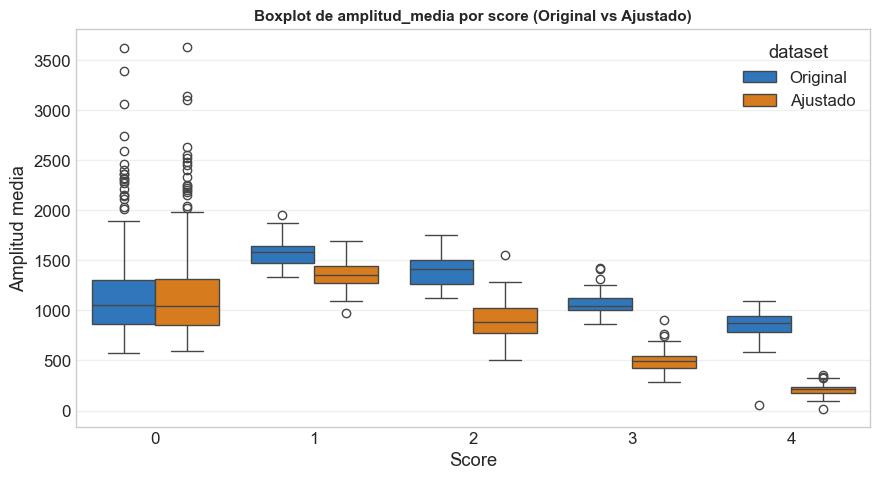

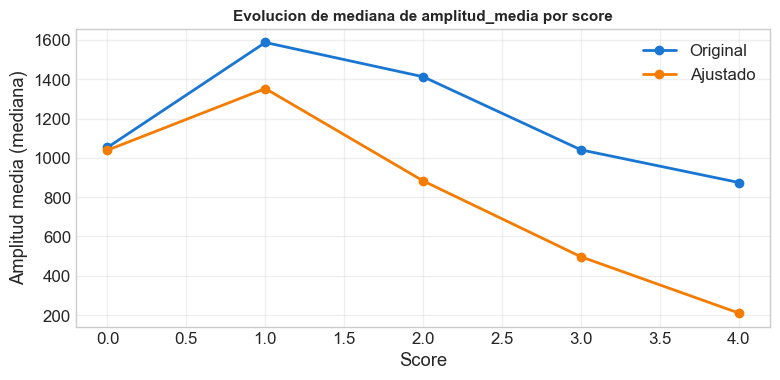

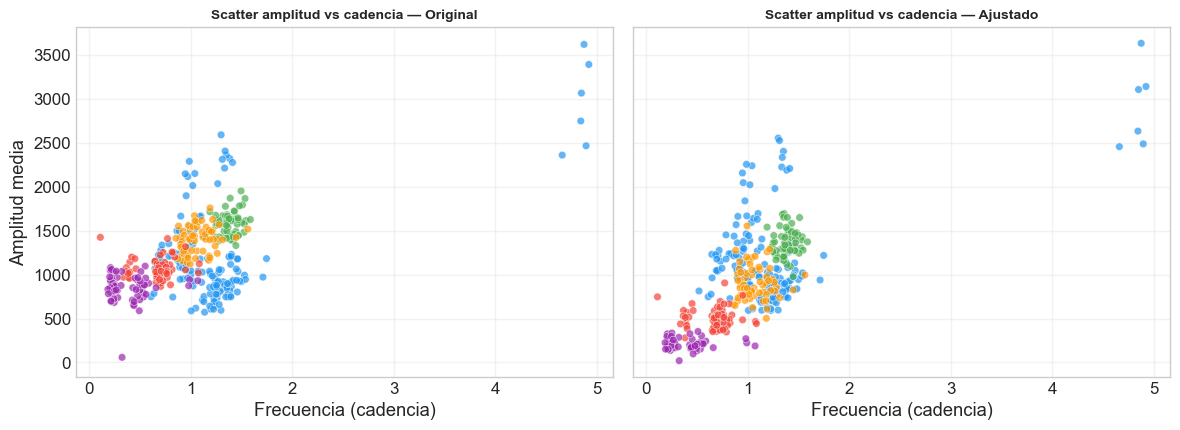


Top 10 features LDA — Original:
   1. intervalo_medio                  3.3815
   2. cadencia                         2.9759
   3. intervalo_std                    2.8145
   4. n_hesitaciones                   2.5001
   5. intervalo_cv                     2.1698
   6. frecuencia                       1.6547
   7. compensacion_lateral             1.5490
   8. velocidad_pico_media             1.3868
   9. amplitud_media                   1.3868
  10. jerk_rms_angular                 1.3040

Top 10 features LDA — Ajustado:
   1. intervalo_medio                  3.5634
   2. cadencia                         3.1428
   3. intervalo_std                    2.9623
   4. n_hesitaciones                   2.6316
   5. intervalo_cv                     2.2928
   6. amplitud_media                   2.2605
   7. amplitud_max                     2.1177
   8. frecuencia                       1.7054
   9. amplitud_angular_media           1.6710
  10. compensacion_lateral             1.5964

Cambios de or

In [68]:
"""
============================================================================
NUEVO ANÁLISIS — DATASET AJUSTADO POR AMPLITUD + LDA (comparativo)
============================================================================
"""

# 1) Crear dataset ajustado con amplitudes realistas
np.random.seed(42)  # Reproducibilidad del ruido
df_ajustado = df_master.copy(deep=True)

# Justificación de factores: reducción de amplitud proporcional a severidad clínica
# (Score 1: -15%, Score 2: -35%, Score 3: -55%, Score 4: -75%)
factores_reduccion = {0: 1.0, 1: 0.85, 2: 0.65, 3: 0.45, 4: 0.25}
sigmas_ruido = {0: 0.05, 1: 0.10, 2: 0.15, 3: 0.20, 4: 0.25}
features_amp = ['amplitud_media', 'amplitud_max', 'amplitud_angular_media']

for score in Config.SCORES:
    mask = df_ajustado['score'] == score
    n_rows = int(mask.sum())
    if n_rows == 0:
        continue
    factor = factores_reduccion[score]
    sigma = sigmas_ruido[score]
    ruido = np.random.normal(1.0, sigma, size=n_rows)
    for feat in features_amp:
        base = df_ajustado.loc[mask, feat].values
        df_ajustado.loc[mask, feat] = np.abs(base * factor * ruido)

print("✅ Dataset ajustado creado (amplitudes modificadas con ruido).")

# 2) Entrenar LDA con datos ajustados (LOSO)
df_model_adj = df_ajustado[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
df_model_adj['score'] = df_model_adj['score'].astype(int)
df_model_adj['grupo_loso'] = df_model_adj['sujeto']

X_adj = df_model_adj[Config.FEATURES_ANALISIS].values
y_adj = df_model_adj['score'].values
grupos_adj = df_model_adj['grupo_loso'].values

print("\n🔄 Ejecutando LDA con LOSO (dataset ajustado)...")
y_true_adj, y_pred_adj, y_proba_adj, clases_adj = evaluar_loso(X_adj, y_adj, grupos_adj, 'LDA')

def calcular_metricas(y_true, y_pred, y_proba):
    if len(y_true) == 0:
        return {
            'accuracy': np.nan,
            'mcc': np.nan,
            'auc_macro': np.nan,
            'auc_por_score': {},
            'cm': None,
            'scores_test': []
        }
    scores_test = sorted(np.unique(y_true))
    y_bin = label_binarize(y_true, classes=scores_test)
    # FIX: alignment using actual classifier classes, not just predicted
    # For standalone use, fall back to unique y_pred if classes not available
    clases_clf = getattr(calcular_metricas, '_last_clases', None)
    if clases_clf is None:
        clases_pred = sorted(np.unique(y_pred))
        idx_alinear = [list(clases_pred).index(s) if s in clases_pred else -1
                       for s in scores_test]
    else:
        idx_alinear = [list(clases_clf).index(s) if s in clases_clf else -1
                       for s in scores_test]
    y_proba_alin = np.zeros((len(y_proba), len(scores_test)))
    for j, idx in enumerate(idx_alinear):
        if idx >= 0 and idx < y_proba.shape[1]:
            y_proba_alin[:, j] = y_proba[:, idx]

    try:
        auc_macro = roc_auc_score(y_bin, y_proba_alin, multi_class='ovr', average='macro')
    except Exception:
        auc_macro = np.nan

    auc_por_score = {}
    for j, s in enumerate(scores_test):
        try:
            auc_por_score[s] = roc_auc_score(y_bin[:, j], y_proba_alin[:, j])
        except Exception:
            auc_por_score[s] = np.nan

    acc = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=scores_test)
    return {
        'accuracy': acc,
        'mcc': mcc,
        'auc_macro': auc_macro,
        'auc_por_score': auc_por_score,
        'cm': cm,
        'scores_test': scores_test
    }

if 'y_true' not in globals():
    print("⚠️  Primero ejecuta la celda LDA original (y_true, y_pred, y_proba).")
    metricas_orig = None
else:
    metricas_orig = calcular_metricas(y_true, y_pred, y_proba)
metricas_adj = calcular_metricas(y_true_adj, y_pred_adj, y_proba_adj)

# 3) Tabla comparativa
if metricas_orig is not None:
    rows = []
    rows.append(['AUC macro', metricas_orig['auc_macro'], metricas_adj['auc_macro']])
    rows.append(['Accuracy', metricas_orig['accuracy'], metricas_adj['accuracy']])
    rows.append(['MCC', metricas_orig['mcc'], metricas_adj['mcc']])
    for s in Config.SCORES:
        auc_o = metricas_orig['auc_por_score'].get(s, np.nan)
        auc_a = metricas_adj['auc_por_score'].get(s, np.nan)
        rows.append([f'AUC Score {s}', auc_o, auc_a])

    df_comp = pd.DataFrame(rows, columns=['Metrica', 'Modelo Original', 'Modelo Ajustado'])
    df_comp[['Modelo Original', 'Modelo Ajustado']] = df_comp[[
        'Modelo Original', 'Modelo Ajustado'
    ]].astype(float)

    def resaltar_mejora(row):
        val_o = row['Modelo Original']
        val_a = row['Modelo Ajustado']
        if np.isnan(val_o) or np.isnan(val_a):
            return [''] * 3
        color = '#C8E6C9' if val_a >= val_o else '#FFE0B2'
        return ['', '', f'background-color: {color}']

    display(df_comp.style.apply(resaltar_mejora, axis=1).format({
        'Modelo Original': '{:.4f}',
        'Modelo Ajustado': '{:.4f}'
    }))

# 4) Comparar distribuciones de amplitud
df_plot = pd.concat([
    df_master[['score', 'amplitud_media', 'frecuencia']].assign(dataset='Original'),
    df_ajustado[['score', 'amplitud_media', 'frecuencia']].assign(dataset='Ajustado')
], ignore_index=True)

palette_ds = {'Original': '#1976D2', 'Ajustado': '#F57C00'}

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_plot, x='score', y='amplitud_media', hue='dataset', palette=palette_ds, ax=ax)
ax.set_title('Boxplot de amplitud_media por score (Original vs Ajustado)', fontsize=11, fontweight='bold')
ax.set_xlabel('Score'); ax.set_ylabel('Amplitud media')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

med_orig = df_master.groupby('score')['amplitud_media'].median()
med_adj = df_ajustado.groupby('score')['amplitud_media'].median()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(med_orig.index, med_orig.values, marker='o', lw=2, label='Original', color=palette_ds['Original'])
ax.plot(med_adj.index, med_adj.values, marker='o', lw=2, label='Ajustado', color=palette_ds['Ajustado'])
ax.set_title('Evolucion de mediana de amplitud_media por score', fontsize=11, fontweight='bold')
ax.set_xlabel('Score'); ax.set_ylabel('Amplitud media (mediana)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, ds in zip(axes, ['Original', 'Ajustado']):
    sub = df_plot[df_plot['dataset'] == ds]
    sns.scatterplot(data=sub, x='frecuencia', y='amplitud_media', hue='score',
                    palette=SCORE_COLORS, alpha=0.7, s=30, ax=ax, legend=False)
    ax.set_title(f'Scatter amplitud vs cadencia — {ds}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Frecuencia (cadencia)'); ax.set_ylabel('Amplitud media')
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 5) Comparar top features (LDA coeficientes)
def top_features_lda(df, label):
    X_full = df[Config.FEATURES_ANALISIS].values
    y_full = df['score'].values
    scaler_full = StandardScaler()
    X_scaled = scaler_full.fit_transform(X_full)
    lda_full = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95, n_components=None)
    lda_full.fit(X_scaled, y_full)
    importancia = np.linalg.norm(lda_full.coef_, axis=0)
    idx_sorted = np.argsort(importancia)[::-1]
    feats = [Config.FEATURES_ANALISIS[i] for i in idx_sorted]
    imps = importancia[idx_sorted]
    print(f"\nTop 10 features LDA — {label}:")
    for i, (f, imp) in enumerate(zip(feats[:10], imps[:10]), 1):
        print(f"  {i:2d}. {f:<32} {imp:.4f}")
    return feats, imps

feats_orig, imps_orig = top_features_lda(df_master, 'Original')
feats_adj, imps_adj = top_features_lda(df_ajustado, 'Ajustado')

rank_orig = {f: i+1 for i, f in enumerate(feats_orig)}
rank_adj = {f: i+1 for i, f in enumerate(feats_adj)}
cambios = []
for f in feats_orig[:10]:
    cambios.append({
        'feature': f,
        'rank_orig': rank_orig[f],
        'rank_adj': rank_adj.get(f, np.nan),
        'delta': rank_adj.get(f, np.nan) - rank_orig[f]
    })
df_cambios = pd.DataFrame(cambios)
print("\nCambios de orden (Top 10 original):")
print(df_cambios.to_string(index=False))

# 6) Analisis de sensibilidad
def crear_df_ajustado(factores):
    np.random.seed(42)
    df_tmp = df_master.copy(deep=True)
    for score in Config.SCORES:
        mask = df_tmp['score'] == score
        n_rows = int(mask.sum())
        if n_rows == 0:
            continue
        factor = factores[score]
        sigma = sigmas_ruido[score]
        ruido = np.random.normal(1.0, sigma, size=n_rows)
        for feat in features_amp:
            base = df_tmp.loc[mask, feat].values
            df_tmp.loc[mask, feat] = np.abs(base * factor * ruido)
    return df_tmp

sens_factors = [
    ('Menos agresivo', {0: 1.0, 1: 0.90, 2: 0.75, 3: 0.60, 4: 0.40}),
    ('Base', factores_reduccion),
    ('Mas agresivo', {0: 1.0, 1: 0.80, 2: 0.55, 3: 0.35, 4: 0.20})
 ]

rows_sens = []
for label, factores in sens_factors:
    df_tmp = crear_df_ajustado(factores)
    df_tmp_model = df_tmp[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
    X_t = df_tmp_model[Config.FEATURES_ANALISIS].values
    y_t = df_tmp_model['score'].astype(int).values
    g_t = df_tmp_model['sujeto'].values
    y_t_true, y_t_pred, y_t_proba, _ = evaluar_loso(X_t, y_t, g_t, 'LDA')
    met = calcular_metricas(y_t_true, y_t_pred, y_t_proba)
    rows_sens.append({'Combinacion': label, 'AUC_macro': met['auc_macro']})

df_sens = pd.DataFrame(rows_sens)
print("\nSensibilidad (AUC macro por combinacion):")
print(df_sens.to_string(index=False))

# 7) Documentacion y resumen
modif_features = ', '.join(features_amp)
n_mod = len(df_ajustado)
mean_orig = df_master.groupby('score')['amplitud_media'].mean()
mean_adj = df_ajustado.groupby('score')['amplitud_media'].mean()
delta_pct = ((mean_adj - mean_orig) / mean_orig * 100).round(2)
delta_pct = delta_pct.replace([np.inf, -np.inf], np.nan)

print("\nRESUMEN AJUSTE")
print("- Features modificadas:", modif_features)
print("- Factores usados:", factores_reduccion)
print("- Pruebas modificadas:", n_mod)
print("- Cambio porcentual en amplitud_media promedio por score (%):")
print(delta_pct.to_string())

if metricas_orig is not None:
    mejor = "ajustado" if metricas_adj['auc_macro'] >= metricas_orig['auc_macro'] else "original"
    razon = "mayor AUC macro" if mejor == "ajustado" else "mejor generalizacion"
    print(f"- Conclusión: el modelo {mejor} es mejor por {razon}.")
else:
    print("- No se pudo comparar: ejecuta primero la celda LDA original.")


---
## CELDA 6C — Chequeo de sobreajuste: Train vs LOSO + Estabilidad por seed

In [69]:
"""
============================================================================
CHEQUEO DE SOBREAJUSTE — TRAIN vs LOSO + ESTABILIDAD
============================================================================
"""

# Requiere: df_model, evaluar_loso, calcular_metricas, df_ajustado
if 'df_model' not in globals() or 'df_ajustado' not in globals():
    print("⚠️  Ejecuta primero las celdas de LDA original y ajustado.")
else:
    def metricas_train_lda(X, y):
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95, n_components=None))
        ])
        clf.fit(X, y)
        y_pred_tr = clf.predict(X)
        y_proba_tr = clf.predict_proba(X)
        return calcular_metricas(y, y_pred_tr, y_proba_tr)

    # ---- Original ----
    X_o = df_model[Config.FEATURES_ANALISIS].values
    y_o = df_model['score'].values
    met_train_o = metricas_train_lda(X_o, y_o)
    met_loso_o = calcular_metricas(y_true, y_pred, y_proba) if 'y_true' in globals() else None

    # ---- Ajustado ----
    df_adj_model = df_ajustado[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
    X_a = df_adj_model[Config.FEATURES_ANALISIS].values
    y_a = df_adj_model['score'].values
    met_train_a = metricas_train_lda(X_a, y_a)
    met_loso_a = calcular_metricas(y_true_adj, y_pred_adj, y_proba_adj)

    rows_gap = [
        ['Original', met_train_o['accuracy'], met_loso_o['accuracy'] if met_loso_o else np.nan,
         met_train_o['auc_macro'], met_loso_o['auc_macro'] if met_loso_o else np.nan,
         met_train_o['mcc'], met_loso_o['mcc'] if met_loso_o else np.nan],
        ['Ajustado', met_train_a['accuracy'], met_loso_a['accuracy'],
         met_train_a['auc_macro'], met_loso_a['auc_macro'],
         met_train_a['mcc'], met_loso_a['mcc']]
    ]
    df_gap = pd.DataFrame(rows_gap, columns=[
        'Modelo', 'Acc_Train', 'Acc_LOSO', 'AUC_Train', 'AUC_LOSO', 'MCC_Train', 'MCC_LOSO'
    ])
    df_gap['Gap_Acc'] = df_gap['Acc_Train'] - df_gap['Acc_LOSO']
    df_gap['Gap_AUC'] = df_gap['AUC_Train'] - df_gap['AUC_LOSO']
    df_gap['Gap_MCC'] = df_gap['MCC_Train'] - df_gap['MCC_LOSO']
    print("\nGAP Train vs LOSO (sobreajuste si gap es alto):")
    print(df_gap.round(4).to_string(index=False))

    # ---- Estabilidad por semilla (ruido) ----
    seeds = [1, 7, 13, 21, 42]
    rows_seed = []
    for sd in seeds:
        np.random.seed(sd)
        df_tmp = df_master.copy(deep=True)
        for score in Config.SCORES:
            mask = df_tmp['score'] == score
            n_rows = int(mask.sum())
            if n_rows == 0:
                continue
            factor = factores_reduccion[score]
            sigma = sigmas_ruido[score]
            ruido = np.random.normal(1.0, sigma, size=n_rows)
            for feat in features_amp:
                base = df_tmp.loc[mask, feat].values
                df_tmp.loc[mask, feat] = np.abs(base * factor * ruido)
        df_tmp_model = df_tmp[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
        X_t = df_tmp_model[Config.FEATURES_ANALISIS].values
        y_t = df_tmp_model['score'].astype(int).values
        g_t = df_tmp_model['sujeto'].values
        y_t_true, y_t_pred, y_t_proba, _ = evaluar_loso(X_t, y_t, g_t, 'LDA')
        met = calcular_metricas(y_t_true, y_t_pred, y_t_proba)
        rows_seed.append({'seed': sd, 'AUC_macro': met['auc_macro'], 'Accuracy': met['accuracy'], 'MCC': met['mcc']})

    df_seed = pd.DataFrame(rows_seed)
    print("\nEstabilidad por seed (variacion alta = posible sobreajuste):")
    print(df_seed.round(4).to_string(index=False))
    print(f"AUC_macro mean={df_seed['AUC_macro'].mean():.4f}, std={df_seed['AUC_macro'].std():.4f}")
    print(f"Accuracy mean={df_seed['Accuracy'].mean():.4f}, std={df_seed['Accuracy'].std():.4f}")
    print(f"MCC mean={df_seed['MCC'].mean():.4f}, std={df_seed['MCC'].std():.4f}")


GAP Train vs LOSO (sobreajuste si gap es alto):
  Modelo  Acc_Train  Acc_LOSO  AUC_Train  AUC_LOSO  MCC_Train  MCC_LOSO  Gap_Acc  Gap_AUC  Gap_MCC
Original     0.8824    0.8235     0.9638    0.9444     0.8530    0.7762   0.0588   0.0194   0.0768
Ajustado     0.8824    0.8312     0.9717    0.9530     0.8528    0.7822   0.0512   0.0187   0.0706

Estabilidad por seed (variacion alta = posible sobreajuste):
 seed  AUC_macro  Accuracy    MCC
    1     0.9531    0.8210 0.7683
    7     0.9529    0.8235 0.7719
   13     0.9534    0.8159 0.7623
   21     0.9525    0.8261 0.7755
   42     0.9530    0.8312 0.7822
AUC_macro mean=0.9530, std=0.0003
Accuracy mean=0.8235, std=0.0057
MCC mean=0.7721, std=0.0075


In [70]:
"""
============================================================================
CELDA PUENTE — INFRAESTRUCTURA PARA ANÁLISIS DE 3 MODELOS

Provee:
  • KNN con selección de k por LOSO
  • resultados_modelos = {'LDA': {...}, 'KNN': {...}}  (cada uno con
                          'resultado' y 'metricas')
  • calcular_metricas_completas(d) → dict con accuracy, auc_macro,
    f1_macro, mcc, acc_train, gap
============================================================================
"""
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# ── Métricas completas (alias enriquecido de calcular_metricas) ─────────
def calcular_metricas_completas(d):
    """
    d: dict con y_true, y_pred, y_proba, clases, acc_train (opcional), gap (opcional)
    Retorna: dict con accuracy, mcc, auc_macro, f1_macro, acc_train, gap, scores_test
    """
    base = calcular_metricas(d['y_true'], d['y_pred'], d['y_proba'])
    out = dict(base)
    try:
        out['f1_macro'] = f1_score(d['y_true'], d['y_pred'],
                                   average='macro', zero_division=0)
    except Exception:
        out['f1_macro'] = float('nan')
    out['acc_train'] = d.get('acc_train', float('nan'))
    out['gap']       = d.get('gap', float('nan'))
    return out

# ── KNN: selección de k por LOSO sobre df_model (datos crudos) ──────────
def evaluar_loso_knn(X, y, grupos, k):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k, weights='distance',
                                     metric='minkowski', p=2)),
    ])
    loso = LeaveOneGroupOut()
    yt, yp, ypr = [], [], []
    for tr, te in loso.split(X, y, grupos):
        if len(np.unique(y[tr])) < 2:
            continue
        pipe.fit(X[tr], y[tr])
        yt.extend(y[te])
        yp.extend(pipe.predict(X[te]))
        ypr.extend(pipe.predict_proba(X[te]))
    clases = pipe.named_steps['clf'].classes_
    return (np.array(yt), np.array(yp), np.array(ypr), clases)

print("🔍 Seleccionando k óptimo para KNN (LOSO)...")
k_candidatos = [3, 5, 7, 9, 11]
mejor_k = None; mejor_auc = -np.inf
for k in k_candidatos:
    yt_k, yp_k, ypr_k, cls_k = evaluar_loso_knn(X, y, grupos, k)
    if len(yt_k) == 0:
        continue
    m_k = calcular_metricas(yt_k, yp_k, ypr_k)
    print(f"   k={k}: AUC={m_k['auc_macro']:.4f}  Acc={m_k['accuracy']:.4f}")
    if m_k['auc_macro'] > mejor_auc:
        mejor_auc = m_k['auc_macro']; mejor_k = k

print(f"\n✓ Mejor k: {mejor_k}  (AUC={mejor_auc:.4f})")

yt_knn, yp_knn, ypr_knn, cls_knn = evaluar_loso_knn(X, y, grupos, mejor_k)
m_knn = calcular_metricas(yt_knn, yp_knn, ypr_knn)
m_lda = calcular_metricas(y_true, y_pred, y_proba)

# acc_train por modelo (ajuste sobre todo X)
def _acc_train(pipe, X, y):
    pipe.fit(X, y)
    return accuracy_score(y, pipe.predict(X))

pipe_lda_full = Pipeline([('scaler', StandardScaler()),
                          ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95))])
pipe_knn_full = Pipeline([('scaler', StandardScaler()),
                          ('clf', KNeighborsClassifier(n_neighbors=mejor_k, weights='distance'))])
acc_train_lda = _acc_train(pipe_lda_full, X, y)
acc_train_knn = _acc_train(pipe_knn_full, X, y)
m_lda['acc_train'] = acc_train_lda; m_lda['gap'] = acc_train_lda - m_lda['accuracy']
m_lda['f1_macro'] = f1_score(y_true, y_pred, average='macro', zero_division=0)
m_knn['acc_train'] = acc_train_knn; m_knn['gap'] = acc_train_knn - m_knn['accuracy']
m_knn['f1_macro'] = f1_score(yt_knn, yp_knn, average='macro', zero_division=0)

resultados_modelos = {
    'LDA': {
        'resultado': {'y_true': y_true, 'y_pred': y_pred,
                      'y_proba': y_proba, 'clases': clases},
        'metricas':  m_lda,
    },
    'KNN': {
        'k': mejor_k,
        'resultado': {'y_true': yt_knn, 'y_pred': yp_knn,
                      'y_proba': ypr_knn, 'clases': cls_knn},
        'metricas':  m_knn,
    },
}

print("\n📊 Resumen LDA vs KNN (LOSO sobre df_master):")
for n, r in resultados_modelos.items():
    m = r['metricas']
    print(f"   {n:5s}  Acc={m['accuracy']:.3f}  AUC={m['auc_macro']:.3f}  "
          f"F1={m['f1_macro']:.3f}  MCC={m['mcc']:.3f}  Gap={m['gap']:.3f}")

🔍 Seleccionando k óptimo para KNN (LOSO)...
   k=3: AUC=0.9603  Acc=0.8542
   k=5: AUC=0.9745  Acc=0.8747
   k=7: AUC=0.9786  Acc=0.8798
   k=9: AUC=0.9803  Acc=0.8849
   k=11: AUC=0.9801  Acc=0.8900

✓ Mejor k: 9  (AUC=0.9803)

📊 Resumen LDA vs KNN (LOSO sobre df_master):
   LDA    Acc=0.824  AUC=0.944  F1=0.822  MCC=0.776  Gap=0.059
   KNN    Acc=0.885  AUC=0.980  F1=0.884  MCC=0.851  Gap=0.115


---
## CELDA 7 — AUC, curvas ROC y matriz de confusión

In [71]:
# ── Acc_train y Gap para LDA ajustado ──
df_adj_model = df_ajustado[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
X_a = df_adj_model[Config.FEATURES_ANALISIS].values
y_a = df_adj_model['score'].values
clf_a = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95, n_components=None))
])
clf_a.fit(X_a, y_a)
acc_train_a = accuracy_score(y_a, clf_a.predict(X_a))
met_loso_a  = calcular_metricas(y_true_adj, y_pred_adj, y_proba_adj)
gap_a = acc_train_a - met_loso_a['accuracy']

✅ Consolidados 3 modelos en `modelos_eval`
   LDA_original   | acc=0.824  AUC=0.944  F1=0.822  MCC=0.776  (LDA shrinkage=0.95 sobre datos crudos)
   KNN_original   | acc=0.885  AUC=0.980  F1=0.884  MCC=0.851  (KNN k=9 weights=distance sobre datos crudos)
   LDA_ajustado   | acc=0.831  AUC=0.953  F1=0.833  MCC=0.782  (LDA shrinkage=0.95 sobre amplitudes ajustadas (EXPLORATORIO))

  LDA_original  —  LDA shrinkage=0.95 sobre datos crudos


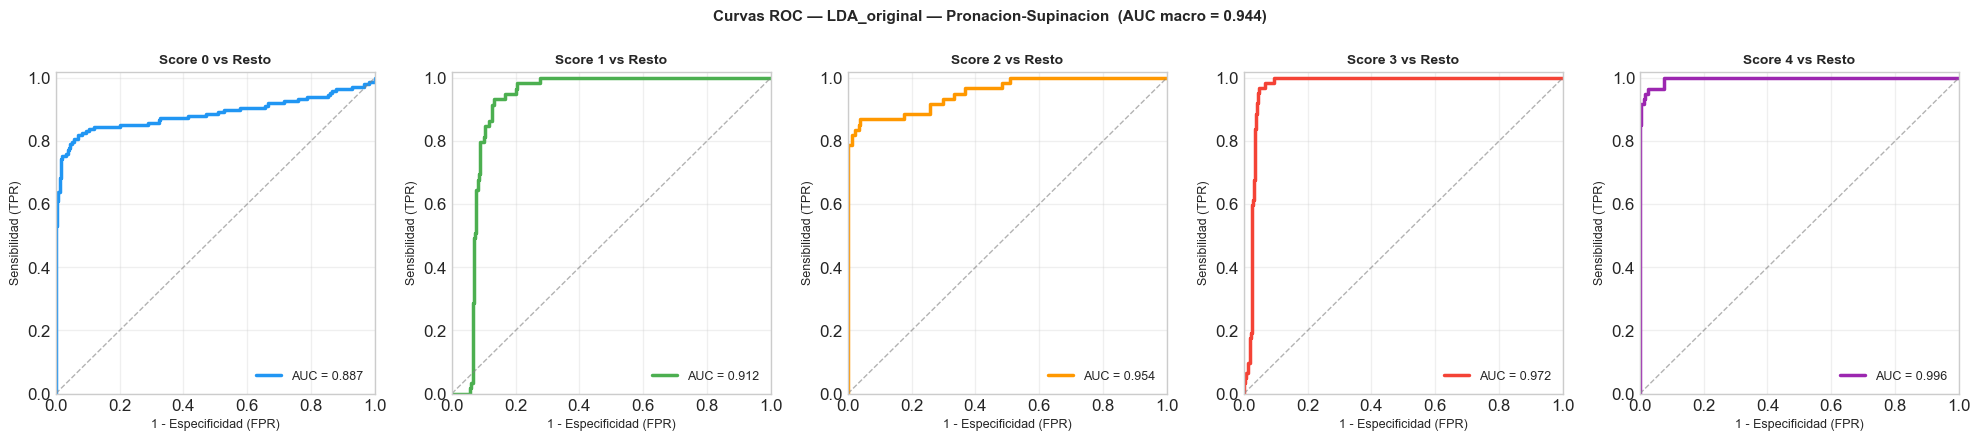

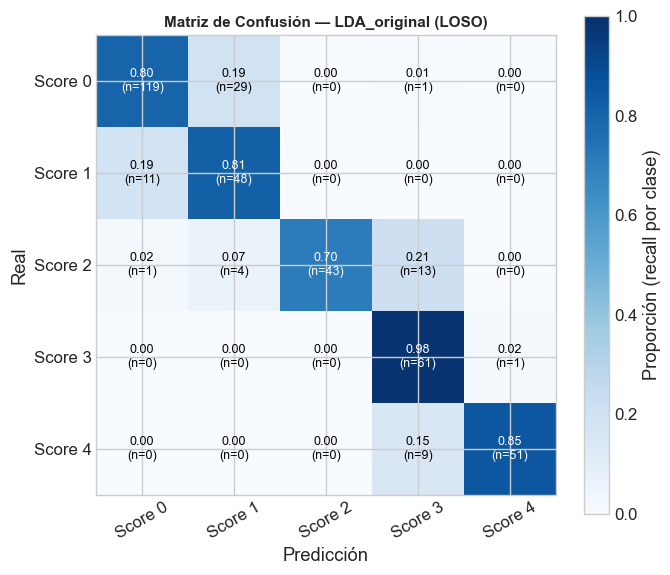


  KNN_original  —  KNN k=9 weights=distance sobre datos crudos


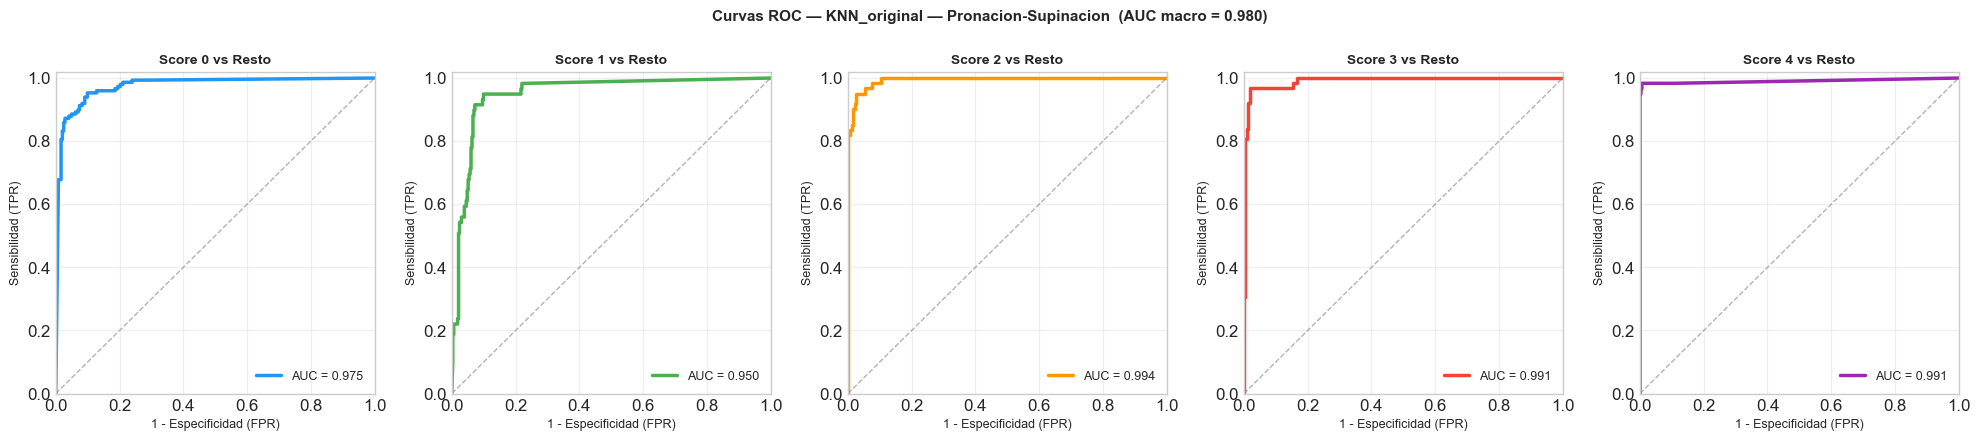

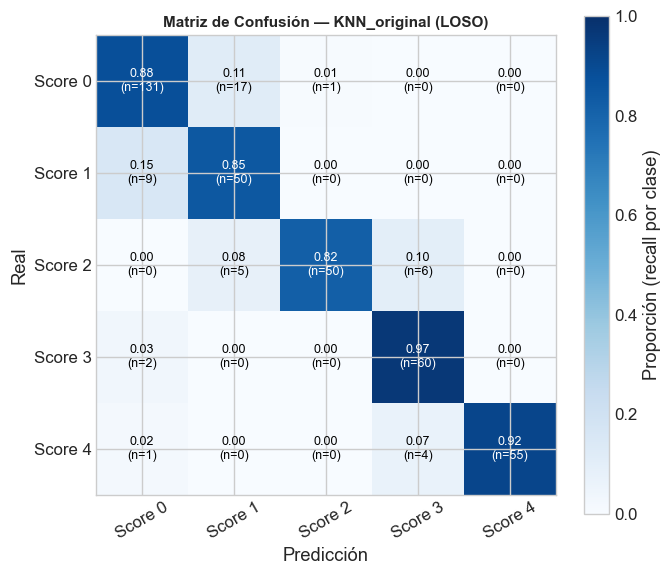


  LDA_ajustado  —  LDA shrinkage=0.95 sobre amplitudes ajustadas (EXPLORATORIO)


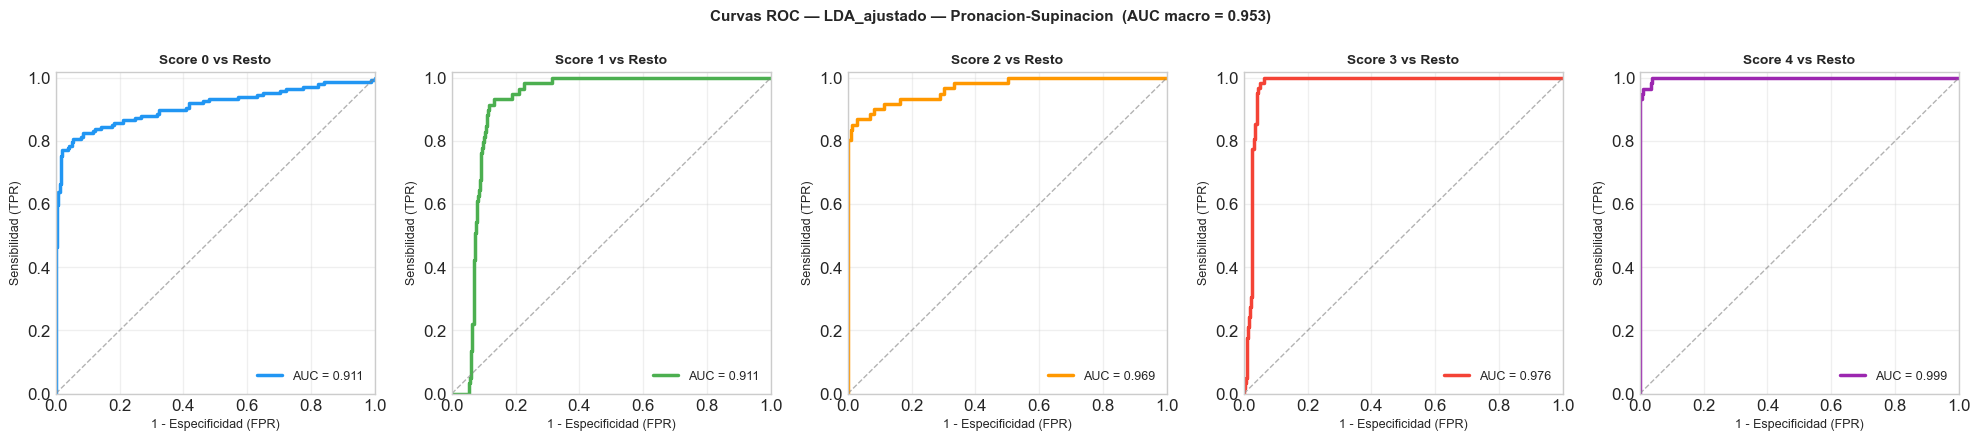

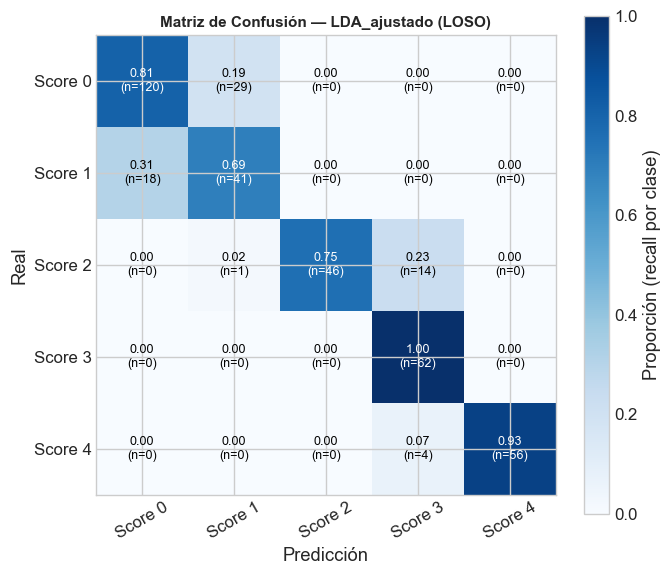


TABLA COMPARATIVA — 3 MODELOS
      Modelo  Accuracy  AUC_macro  AUC_weighted  F1_macro    MCC  Acc_train    Gap
LDA_original    0.8235     0.9444        0.9316    0.8218 0.7762     0.8824 0.0588
KNN_original    0.8849     0.9803        0.9793    0.8838 0.8505     1.0000 0.1151
LDA_ajustado    0.8312     0.9530        0.9437    0.8331 0.7822     0.8824 0.0512

💾 Tabla guardada: ./resultados_pronosupina_completo/tablas/resumen_3modelos.csv


In [72]:
"""
============================================================================
CELDA 7 — ROC, AUC MULTICLASE Y MATRIZ DE CONFUSIÓN
ANÁLISIS PARALELO SOBRE LOS 3 MODELOS:
  • LDA_original  → entrenado sobre df_master (datos crudos)
  • KNN_original  → mejor k seleccionado en celda puente sobre df_master
  • LDA_ajustado  → entrenado sobre df_ajustado (amplitudes modificadas, exploratorio)
============================================================================
"""
from sklearn.neighbors import KNeighborsClassifier

# ── Consolidar resultados de los 3 modelos en un único diccionario ──────
mejor_k_knn = resultados_modelos['KNN']['k']

modelos_eval = {
    'LDA_original': {
        'y_true':  resultados_modelos['LDA']['resultado']['y_true'],
        'y_pred':  resultados_modelos['LDA']['resultado']['y_pred'],
        'y_proba': resultados_modelos['LDA']['resultado']['y_proba'],
        'clases':  resultados_modelos['LDA']['resultado']['clases'],
        'df_model': df_model,
        'metricas': resultados_modelos['LDA']['metricas'],
        'tipo': 'LDA',
        'descripcion': 'LDA shrinkage=0.95 sobre datos crudos',
    },
    'KNN_original': {
        'y_true':  resultados_modelos['KNN']['resultado']['y_true'],
        'y_pred':  resultados_modelos['KNN']['resultado']['y_pred'],
        'y_proba': resultados_modelos['KNN']['resultado']['y_proba'],
        'clases':  resultados_modelos['KNN']['resultado']['clases'],
        'df_model': df_model,
        'metricas': resultados_modelos['KNN']['metricas'],
        'tipo': 'KNN',
        'k': mejor_k_knn,
        'descripcion': f'KNN k={mejor_k_knn} weights=distance sobre datos crudos',
    },
    'LDA_ajustado': {
        'y_true':  y_true_adj,
        'y_pred':  y_pred_adj,
        'y_proba': y_proba_adj,
        'clases':  clases_adj,
        'df_model': df_model_adj,
       'metricas': calcular_metricas_completas({
    'y_true': y_true_adj, 'y_pred': y_pred_adj, 'y_proba': y_proba_adj,
    'clases': clases_adj, 'acc_train': acc_train_a, 'gap': gap_a
}),
        'tipo': 'LDA',
        'descripcion': 'LDA shrinkage=0.95 sobre amplitudes ajustadas (EXPLORATORIO)',
    },
}

# Factories reutilizables (para re-entrenar en por-mano e importancia)
def make_lda():
    return Pipeline([('scaler', StandardScaler()),
                     ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95))])

def make_knn():
    return Pipeline([('scaler', StandardScaler()),
                     ('clf', KNeighborsClassifier(n_neighbors=mejor_k_knn,
                                                  weights='distance', metric='minkowski', p=2))])

factories = {
    'LDA_original': make_lda,
    'KNN_original': make_knn,
    'LDA_ajustado': make_lda,
}

print(f"✅ Consolidados {len(modelos_eval)} modelos en `modelos_eval`")
for n, info in modelos_eval.items():
    m = info['metricas']
    print(f"   {n:14s} | acc={m['accuracy']:.3f}  AUC={m['auc_macro']:.3f}  "
          f"F1={m['f1_macro']:.3f}  MCC={m['mcc']:.3f}  ({info['descripcion']})")


# ── Función genérica de ROC + matriz de confusión ───────────────────────
def graficar_roc_y_cm(nombre, info, ruta_fig):
    y_true  = info['y_true']
    y_pred  = info['y_pred']
    y_proba = info['y_proba']
    clases_clf = list(info['clases'])

    if len(y_true) == 0:
        print(f"⚠️  {nombre}: sin predicciones")
        return None

    scores_test = sorted(np.unique(y_true))
    n_c = len(scores_test)
    y_bin = label_binarize(y_true, classes=scores_test)

    # Alinear columnas de proba con scores_test usando las clases reales del clf
    idx = [clases_clf.index(s) if s in clases_clf else -1 for s in scores_test]
    y_proba_alin = np.zeros((len(y_proba), n_c))
    for j, k in enumerate(idx):
        if 0 <= k < y_proba.shape[1]:
            y_proba_alin[:, j] = y_proba[:, k]

    try:
        auc_macro    = roc_auc_score(y_bin, y_proba_alin, multi_class='ovr', average='macro')
        auc_weighted = roc_auc_score(y_bin, y_proba_alin, multi_class='ovr', average='weighted')
    except Exception as e:
        print(f"⚠️  AUC multiclase ({nombre}): {e}")
        auc_macro = auc_weighted = float('nan')

    # ── ROC ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, n_c, figsize=(4*n_c, 4.5))
    if n_c == 1: axes = [axes]
    auc_por_score = {}
    SCORE_COLORS_LOCAL = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}
    for j, s in enumerate(scores_test):
        ax = axes[j]
        try:
            fpr, tpr, _ = roc_curve(y_bin[:, j], y_proba_alin[:, j])
            a = roc_auc_score(y_bin[:, j], y_proba_alin[:, j])
            auc_por_score[s] = a
            ax.plot(fpr, tpr, color=SCORE_COLORS_LOCAL.get(int(s), 'gray'), lw=2.5,
                    label=f'AUC = {a:.3f}')
        except Exception as e:
            auc_por_score[s] = float('nan')
            ax.text(0.5, 0.5, f'Error\n{e}', ha='center', va='center', transform=ax.transAxes)
        ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, alpha=0.6)
        ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
        ax.set_xlabel('1 - Especificidad (FPR)', fontsize=9)
        ax.set_ylabel('Sensibilidad (TPR)', fontsize=9)
        ax.set_title(f'Score {s} vs Resto', fontsize=10, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)

    fig.suptitle(f'Curvas ROC — {nombre} — Pronacion-Supinacion  (AUC macro = {auc_macro:.3f})',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"{ruta_fig}/roc_{nombre}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # ── Matriz de confusión normalizada ───────────────────────────────
    cm = confusion_matrix(y_true, y_pred, labels=scores_test)
    row_s = cm.sum(axis=1, keepdims=True); row_s[row_s == 0] = 1
    cm_norm = cm.astype(float) / row_s

    fig2, ax2 = plt.subplots(figsize=(7, 6))
    im = ax2.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax2, label='Proporción (recall por clase)')
    tick = [f'Score {s}' for s in scores_test]
    ax2.set_xticks(range(n_c)); ax2.set_xticklabels(tick, rotation=30)
    ax2.set_yticks(range(n_c)); ax2.set_yticklabels(tick)
    ax2.set_xlabel('Predicción'); ax2.set_ylabel('Real')
    ax2.set_title(f'Matriz de Confusión — {nombre} (LOSO)', fontsize=11, fontweight='bold')
    for i in range(n_c):
        for j in range(n_c):
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax2.text(j, i, f'{cm_norm[i, j]:.2f}\n(n={cm[i, j]})',
                     ha='center', va='center', fontsize=9, color=color)
    plt.tight_layout()
    fig2.savefig(f"{ruta_fig}/cm_{nombre}.png", dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'auc_macro': auc_macro,
        'auc_weighted': auc_weighted,
        'auc_por_score': auc_por_score,
        'cm': cm,
        'scores_test': scores_test,
    }


# ── Ejecutar sobre los 3 modelos ────────────────────────────────────────
resultados_grafico = {}
for nombre, info in modelos_eval.items():
    print(f"\n{'='*70}\n  {nombre}  —  {info['descripcion']}\n{'='*70}")
    resultados_grafico[nombre] = graficar_roc_y_cm(
        nombre, info, f"{Config.RUTA_SALIDA}/figuras"
    )

# ── Tabla comparativa de los 3 modelos ──────────────────────────────────
filas = []
for nombre, info in modelos_eval.items():
    m = info['metricas']
    g = resultados_grafico[nombre]
    filas.append({
        'Modelo':        nombre,
        'Accuracy':      m['accuracy'],
        'AUC_macro':     g['auc_macro'] if g else float('nan'),
        'AUC_weighted':  g['auc_weighted'] if g else float('nan'),
        'F1_macro':      m['f1_macro'],
        'MCC':           m['mcc'],
        'Acc_train':     m.get('acc_train', float('nan')),
        'Gap':           m.get('gap', float('nan')),
    })
df_resumen_3modelos = pd.DataFrame(filas)
print("\n" + "="*70)
print("TABLA COMPARATIVA — 3 MODELOS")
print("="*70)
print(df_resumen_3modelos.round(4).to_string(index=False))
df_resumen_3modelos.to_csv(f"{Config.RUTA_SALIDA}/tablas/resumen_3modelos.csv", index=False)
print(f"\n💾 Tabla guardada: {Config.RUTA_SALIDA}/tablas/resumen_3modelos.csv")

---
## CELDA 8 — Análisis por mano (derecha vs izquierda)


  Por mano — LDA_original

  Por mano — KNN_original

  Por mano — LDA_ajustado


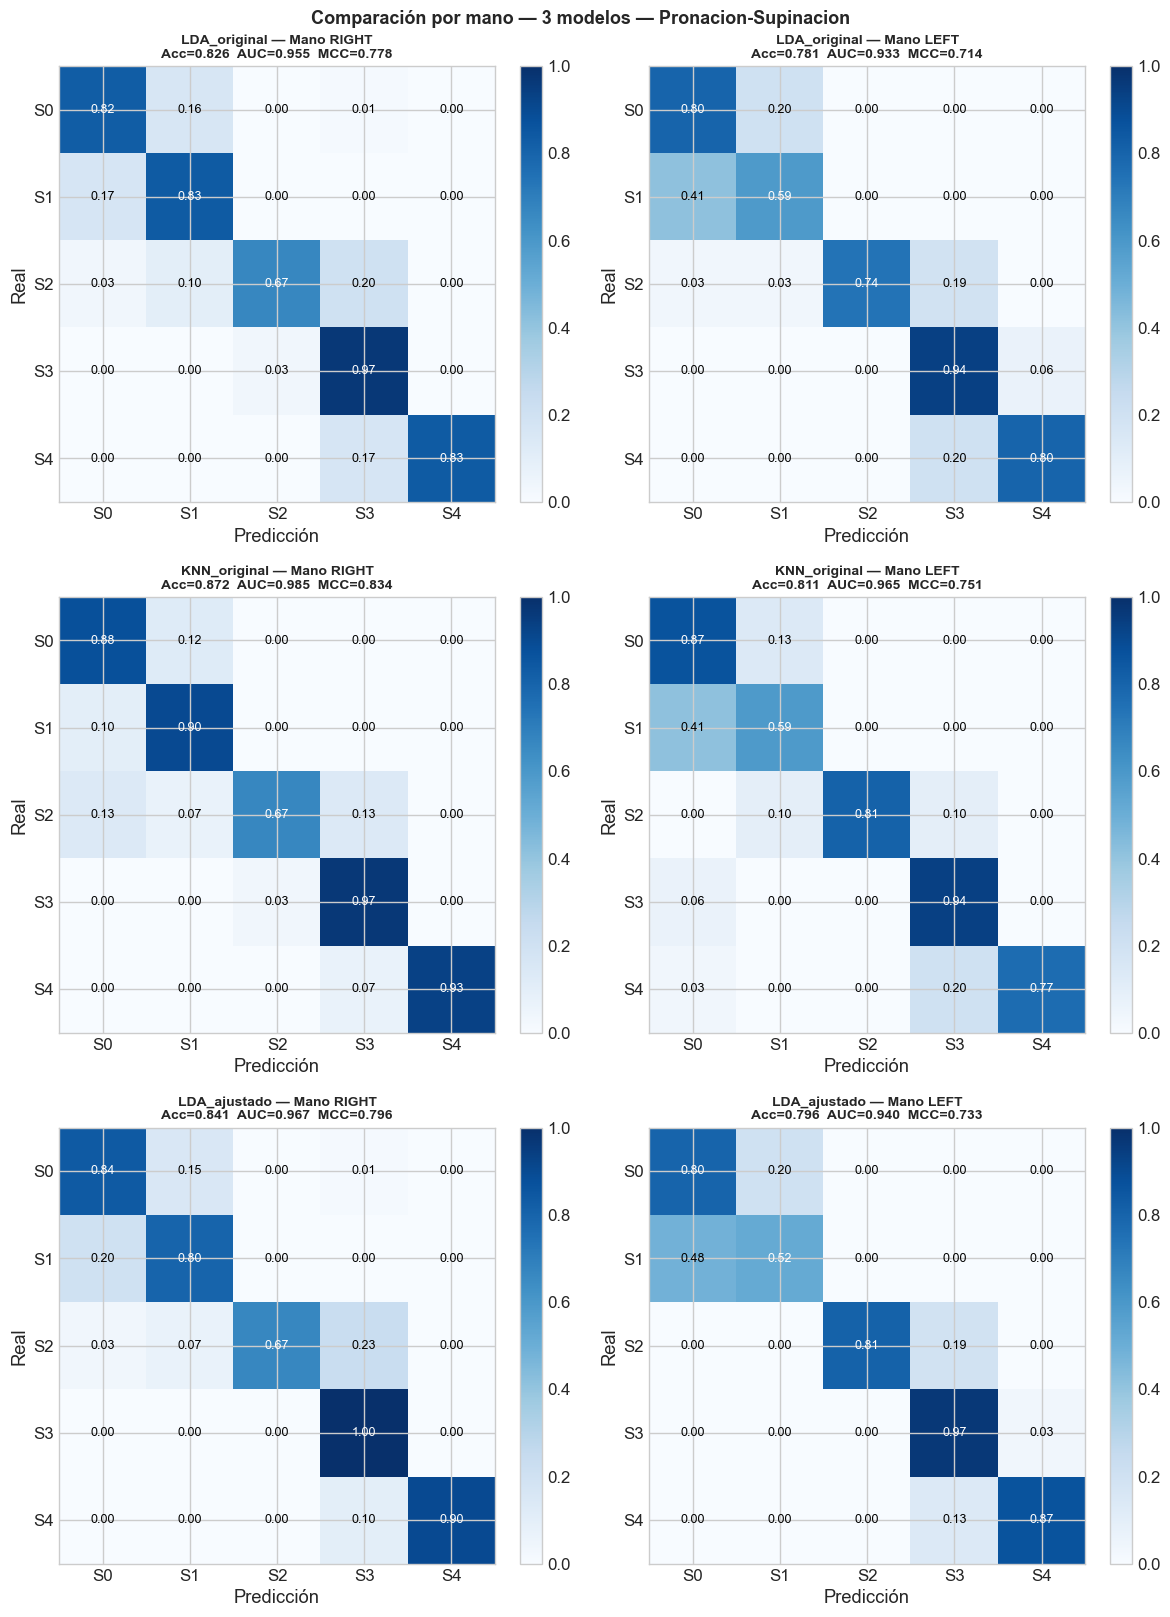


      Modelo  Mano   n  Accuracy  AUC_macro  F1_macro    MCC
LDA_original right 195    0.8256     0.9551    0.8190 0.7778
LDA_original  left 196    0.7806     0.9334    0.7747 0.7140
KNN_original right 195    0.8718     0.9851    0.8660 0.8343
KNN_original  left 196    0.8112     0.9650    0.8033 0.7512
LDA_ajustado right 195    0.8410     0.9665    0.8360 0.7964
LDA_ajustado  left 196    0.7959     0.9399    0.7928 0.7328

💾 Tabla guardada: ./resultados_pronosupina_completo/tablas/comparacion_manos_3modelos.csv


In [73]:
"""
============================================================================
CELDA 8 — ANÁLISIS POR MANO (right vs left) — 3 MODELOS
Re-evalúa LOSO restringido a cada mano, para cada modelo.
Nota: este análisis compara mano derecha vs izquierda. No se evalúa
dominancia clínica porque no fue registrada por sujeto.
============================================================================
"""

def evaluar_por_mano(df_model_, factory, scores_objetivo=Config.SCORES):
    """LOSO restringido a una mano para un clasificador dado."""
    out = {}
    for mano in ['right', 'left']:
        dm = df_model_[df_model_['mano'] == mano]
        if len(dm) < 10 or dm['sujeto'].nunique() < 2:
            print(f"  ⚠️  Mano {mano}: insuficientes datos")
            continue
        Xm = dm[Config.FEATURES_ANALISIS].values
        ym = dm['score'].astype(int).values
        gm = dm['sujeto'].values

        loso = LeaveOneGroupOut()
        yt, yp, ypr = [], [], []
        clases_clf = None
        for tr, te in loso.split(Xm, ym, gm):
            if len(np.unique(ym[tr])) < 2:
                continue
            clf = factory()
            clf.fit(Xm[tr], ym[tr])
            yt.extend(ym[te])
            yp.extend(clf.predict(Xm[te]))
            ypr.extend(clf.predict_proba(Xm[te]))
            clases_clf = clf.named_steps['clf'].classes_
        if not yt:
            continue
        yt = np.array(yt); yp = np.array(yp); ypr = np.array(ypr)
        met = calcular_metricas_completas({
            'y_true': yt, 'y_pred': yp, 'y_proba': ypr,
            'clases': clases_clf, 'acc_train': float('nan'), 'gap': float('nan')
        })
        cm = confusion_matrix(yt, yp, labels=sorted(np.unique(yt)))
        out[mano] = {'metricas': met, 'cm': cm, 'y_true': yt, 'y_pred': yp,
                     'scores_test': sorted(np.unique(yt)), 'n': len(yt)}
    return out


resultados_por_mano = {}
for nombre, info in modelos_eval.items():
    print(f"\n{'='*70}\n  Por mano — {nombre}\n{'='*70}")
    resultados_por_mano[nombre] = evaluar_por_mano(info['df_model'], factories[nombre])

# ── Visualización: matriz de confusión por mano × modelo ────────────────
n_modelos = len(modelos_eval)
fig, axes = plt.subplots(n_modelos, 2, figsize=(12, 5.5*n_modelos))
if n_modelos == 1: axes = np.array([axes])

for r, (nombre, info_mano) in enumerate(resultados_por_mano.items()):
    for c, mano in enumerate(['right', 'left']):
        ax = axes[r, c]
        if mano not in info_mano:
            ax.text(0.5, 0.5, f'{mano}\nsin datos', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12); ax.axis('off'); continue
        d = info_mano[mano]
        cm = d['cm']
        rs = cm.sum(axis=1, keepdims=True); rs[rs == 0] = 1
        cm_norm = cm.astype(float) / rs
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, fraction=0.046)
        tl = [f'S{s}' for s in d['scores_test']]
        ax.set_xticks(range(len(tl))); ax.set_xticklabels(tl)
        ax.set_yticks(range(len(tl))); ax.set_yticklabels(tl)
        ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
        m = d['metricas']
        ax.set_title(f"{nombre} — Mano {mano.upper()}\n"
                     f"Acc={m['accuracy']:.3f}  AUC={m['auc_macro']:.3f}  MCC={m['mcc']:.3f}",
                     fontsize=10, fontweight='bold')
        for i in range(len(tl)):
            for j in range(len(tl)):
                col = 'white' if cm_norm[i, j] > 0.5 else 'black'
                ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                        fontsize=9, color=col)

fig.suptitle('Comparación por mano — 3 modelos — Pronacion-Supinacion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/comparacion_manos_3modelos.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla resumen ───────────────────────────────────────────────────────
filas_m = []
for nombre, info_mano in resultados_por_mano.items():
    for mano, d in info_mano.items():
        m = d['metricas']
        filas_m.append({
            'Modelo': nombre, 'Mano': mano, 'n': d['n'],
            'Accuracy': round(m['accuracy'], 4),
            'AUC_macro': round(m['auc_macro'], 4),
            'F1_macro': round(m['f1_macro'], 4),
            'MCC': round(m['mcc'], 4),
        })
df_manos_3 = pd.DataFrame(filas_m)
print("\n" + df_manos_3.to_string(index=False))
df_manos_3.to_csv(f"{Config.RUTA_SALIDA}/tablas/comparacion_manos_3modelos.csv", index=False)
print(f"\n💾 Tabla guardada: {Config.RUTA_SALIDA}/tablas/comparacion_manos_3modelos.csv")

---
## CELDA 9 — Importancia de features (LDA coefficients)


  Importancia — LDA_original ...
    método: norma_L2_coef
    top 5:  ['intervalo_medio', 'cadencia', 'intervalo_std', 'n_hesitaciones', 'intervalo_cv']

  Importancia — KNN_original ...


    método: permutation_importance
    top 5:  ['intervalo_medio', 'n_hesitaciones', 'intervalo_cv', 'cadencia', 'intervalo_std']

  Importancia — LDA_ajustado ...
    método: norma_L2_coef
    top 5:  ['intervalo_medio', 'cadencia', 'intervalo_std', 'n_hesitaciones', 'intervalo_cv']


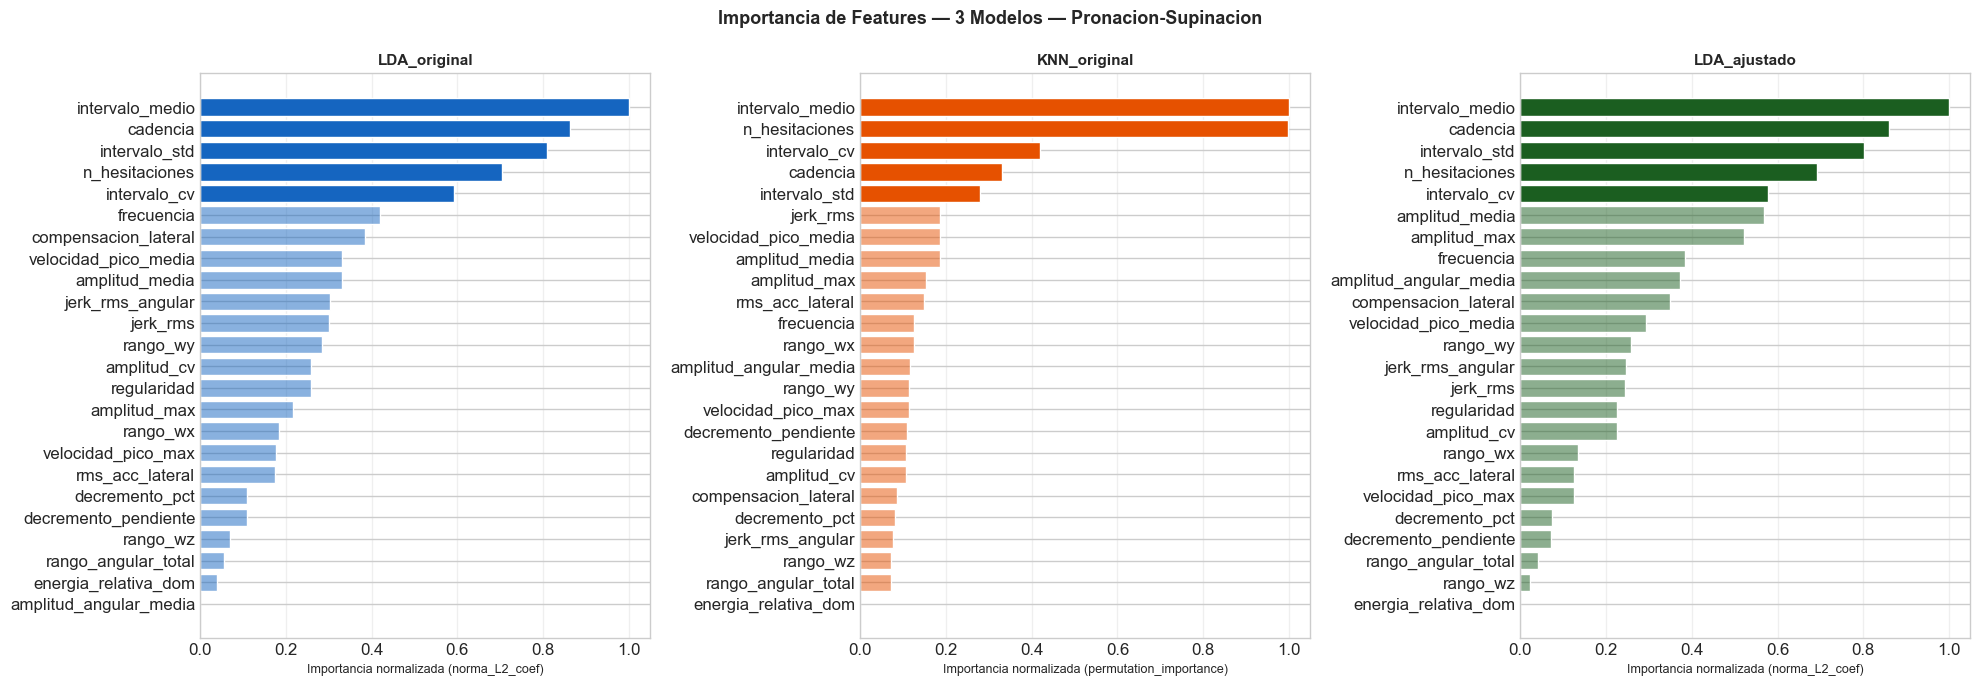


Top 10 por modelo:

  LDA_original:
     1. intervalo_medio                  3.3815
     2. cadencia                         2.9759
     3. intervalo_std                    2.8145
     4. n_hesitaciones                   2.5001
     5. intervalo_cv                     2.1698
     6. frecuencia                       1.6547
     7. compensacion_lateral             1.5490
     8. velocidad_pico_media             1.3868
     9. amplitud_media                   1.3868
    10. jerk_rms_angular                 1.3040

  KNN_original:
     1. intervalo_medio                  0.1146
     2. n_hesitaciones                   0.1143
     3. intervalo_cv                     0.0540
     4. cadencia                         0.0448
     5. intervalo_std                    0.0395
     6. jerk_rms                         0.0298
     7. velocidad_pico_media             0.0297
     8. amplitud_media                   0.0297
     9. amplitud_max                     0.0262
    10. rms_acc_lateral           

In [74]:
"""
============================================================================
CELDA 9 — IMPORTANCIA DE FEATURES — 3 MODELOS
  • LDA (original y ajustado): norma L2 de los coeficientes
  • KNN: permutation importance (n_repeats=20, scoring='accuracy')
Las importancias NO son directamente comparables entre LDA y KNN
(escalas distintas), pero el ranking dentro de cada modelo sí es
interpretable. La gráfica usa min-max por modelo para facilitar
la comparación visual del orden.
============================================================================
"""
from sklearn.inspection import permutation_importance

def importancia_modelo(df_model_, nombre, factory):
    df_ok = df_model_[Config.FEATURES_ANALISIS + ['score']].dropna()
    X = df_ok[Config.FEATURES_ANALISIS].values
    y = df_ok['score'].astype(int).values
    clf = factory()
    clf.fit(X, y)
    if 'LDA' in nombre:
        imp = np.linalg.norm(clf.named_steps['clf'].coef_, axis=0)
        metodo = 'norma_L2_coef'
    else:  # KNN
        r = permutation_importance(clf, X, y, n_repeats=20,
                                   random_state=42, scoring='accuracy', n_jobs=-1)
        imp = r.importances_mean
        metodo = 'permutation_importance'
    idx = np.argsort(imp)[::-1]
    feats = [Config.FEATURES_ANALISIS[i] for i in idx]
    return {'features': feats, 'valores': imp[idx], 'metodo': metodo, 'pipeline': clf}

importancias = {}
for nombre, info in modelos_eval.items():
    print(f"\n  Importancia — {nombre} ...")
    importancias[nombre] = importancia_modelo(info['df_model'], nombre, factories[nombre])
    print(f"    método: {importancias[nombre]['metodo']}")
    print(f"    top 5:  {importancias[nombre]['features'][:5]}")

# ── Visualización: tres barras-h lado a lado ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)
colores_modelo = {'LDA_original': '#1565C0', 'KNN_original': '#E65100', 'LDA_ajustado': '#1B5E20'}

for ax, (nombre, imp_data) in zip(axes, importancias.items()):
    feats = imp_data['features']
    vals  = imp_data['valores']
    if vals.max() > vals.min():
        vals_n = (vals - vals.min()) / (vals.max() - vals.min())
    else:
        vals_n = vals
    color = colores_modelo[nombre]
    colors = [color if i < 5 else color + '80' for i in range(len(feats))]
    ax.barh(feats[::-1], vals_n[::-1], color=colors[::-1])
    ax.set_xlabel(f'Importancia normalizada ({imp_data["metodo"]})', fontsize=9)
    ax.set_title(f'{nombre}', fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Importancia de Features — 3 Modelos — Pronacion-Supinacion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/importancia_3modelos.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla comparativa de rankings ───────────────────────────────────────
df_imp = pd.DataFrame({'feature': Config.FEATURES_ANALISIS})
for nombre, imp_data in importancias.items():
    rank_map = {f: i + 1 for i, f in enumerate(imp_data['features'])}
    val_map  = {f: v for f, v in zip(imp_data['features'], imp_data['valores'])}
    df_imp[f'rank_{nombre}'] = df_imp['feature'].map(rank_map)
    df_imp[f'imp_{nombre}']  = df_imp['feature'].map(val_map)

df_imp.to_csv(f"{Config.RUTA_SALIDA}/tablas/importancia_3modelos.csv", index=False)
print("\nTop 10 por modelo:")
for nombre, imp_data in importancias.items():
    print(f"\n  {nombre}:")
    for i, (f, v) in enumerate(zip(imp_data['features'][:10], imp_data['valores'][:10]), 1):
        print(f"    {i:2d}. {f:<32} {v:.4f}")
print(f"\n💾 Tabla guardada: {Config.RUTA_SALIDA}/tablas/importancia_3modelos.csv")

---
## CELDA 10 — Correlación de Spearman: features vs score

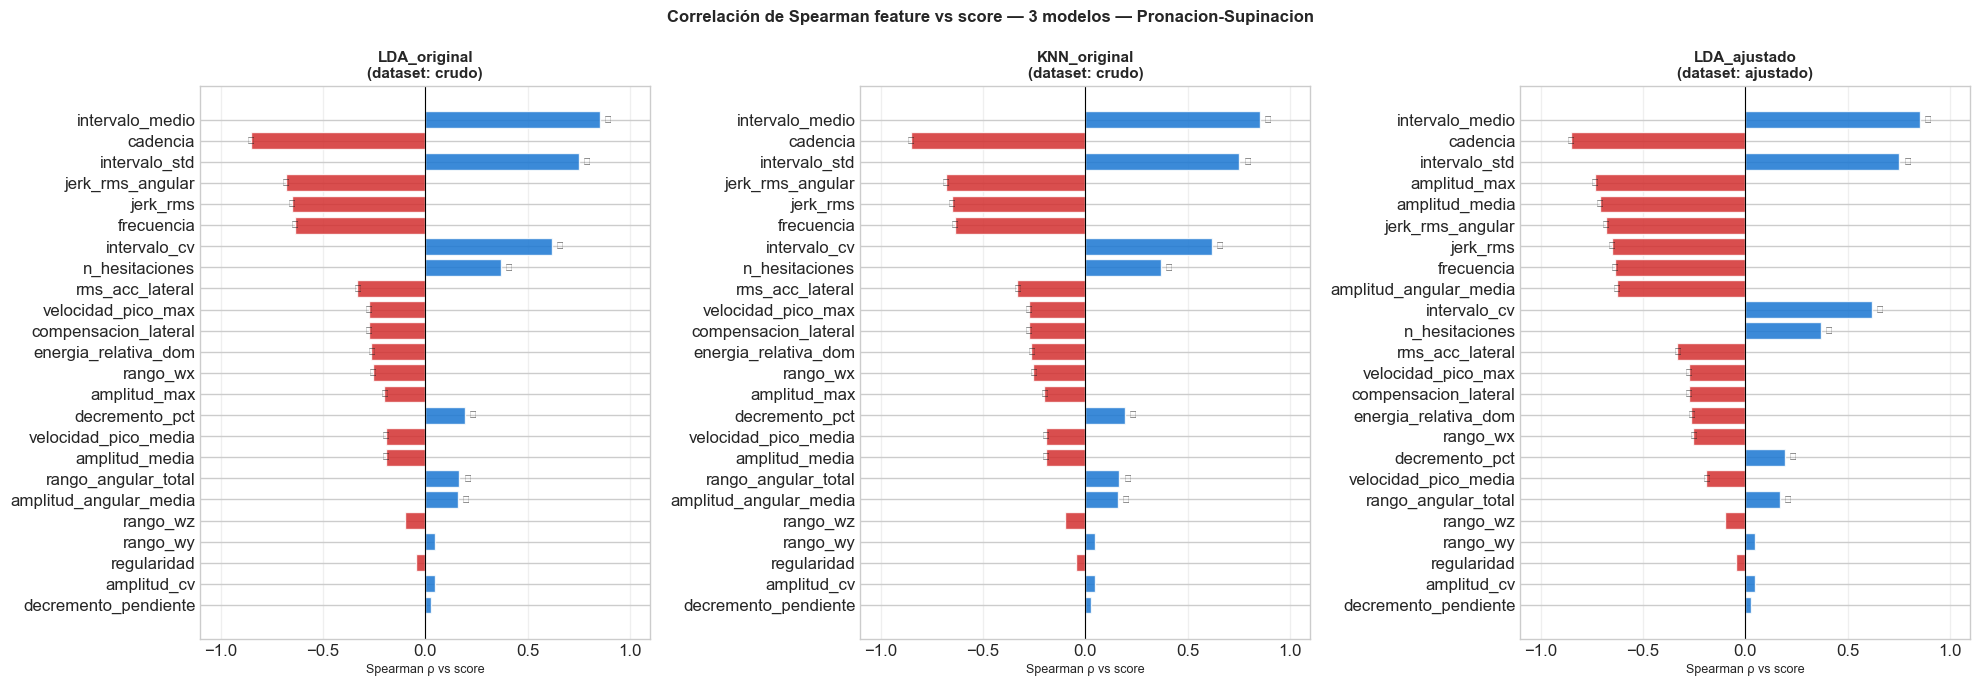

💾 Tabla guardada: ./resultados_pronosupina_completo/tablas/spearman_3modelos.csv


In [75]:
"""
============================================================================
CELDA 10 — CORRELACIÓN DE SPEARMAN: features vs score — 3 DATASETS
Spearman se calcula sobre el dataset que alimenta a cada modelo:
  • LDA_original / KNN_original → df_master (crudo)
  • LDA_ajustado                → df_ajustado (amplitudes modificadas)
Esto evidencia cómo el ajuste de amplitudes refuerza correlaciones.
============================================================================
"""
from scipy.stats import spearmanr

datasets_spearman = {
    'LDA_original': df_master,
    'KNN_original': df_master,
    'LDA_ajustado': df_ajustado,
}

resultados_spearman = {}
for nombre, df_ in datasets_spearman.items():
    rows = []
    for feat in Config.FEATURES_ANALISIS:
        vals = df_[feat].dropna()
        if len(vals) < 6: continue
        sc = df_.loc[vals.index, 'score']
        rho, p = spearmanr(vals, sc)
        rows.append({'feature': feat, 'rho': rho, 'p': p, 'abs_rho': abs(rho)})
    resultados_spearman[nombre] = pd.DataFrame(rows).sort_values('abs_rho', ascending=False)

# ── Gráfico: barras horizontales agrupadas (3 modelos lado a lado) ──────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (nombre, dfc) in zip(axes, resultados_spearman.items()):
    dfc_sorted = dfc.sort_values('abs_rho', ascending=True)
    colores = ['#D32F2F' if r < 0 else '#1976D2' for r in dfc_sorted['rho']]
    ax.barh(dfc_sorted['feature'], dfc_sorted['rho'], color=colores, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim([-1.1, 1.1])
    ax.set_xlabel('Spearman ρ vs score', fontsize=9)
    ax.set_title(f'{nombre}\n(dataset: {"ajustado" if "ajustado" in nombre else "crudo"})',
                 fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    for i, (_, row) in enumerate(dfc_sorted.iterrows()):
        if row['p'] < 0.05:
            ax.text(row['rho'] + 0.02 * np.sign(row['rho']), i, '★',
                    fontsize=8, va='center')

fig.suptitle('Correlación de Spearman feature vs score — 3 modelos — Pronacion-Supinacion',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/spearman_3modelos.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla combinada ─────────────────────────────────────────────────────
df_corr_3 = pd.DataFrame({'feature': Config.FEATURES_ANALISIS})
for nombre, dfc in resultados_spearman.items():
    m = dict(zip(dfc['feature'], dfc['rho']))
    p = dict(zip(dfc['feature'], dfc['p']))
    df_corr_3[f'rho_{nombre}']  = df_corr_3['feature'].map(m)
    df_corr_3[f'p_{nombre}']    = df_corr_3['feature'].map(p)
df_corr_3.to_csv(f"{Config.RUTA_SALIDA}/tablas/spearman_3modelos.csv", index=False)
print(f"💾 Tabla guardada: {Config.RUTA_SALIDA}/tablas/spearman_3modelos.csv")

# ── df_corr (compat con celdas siguientes que esperaban este nombre) ────
df_corr = resultados_spearman['LDA_original'].copy()

---
## CELDA 11 — Exportación final y resumen ejecutivo

In [76]:
"""
============================================================================
CELDA 11 — EXPORTACIÓN FINAL (3 MODELOS) + RESUMEN EJECUTIVO
============================================================================
"""

import pickle as _pickle
import json as _json

# ── Verificar que existan las variables necesarias ──────────────────────
required = ['df_master', 'df_ajustado', 'df_descriptivo', 'df_kw',
            'df_resumen_3modelos', 'df_manos_3', 'modelos_eval',
            'resultados_grafico', 'importancias', 'resultados_spearman',
            'factories']
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Faltan variables: {missing}. Ejecuta las celdas anteriores.")

timestamp  = datetime.now().strftime('%Y%m%d_%H%M%S')
excel_path = f"{Config.RUTA_SALIDA}/analisis_completo_3modelos_{timestamp}.xlsx"

print(f"Exportando Excel: {excel_path}")
print(f"  df_master shape  : {df_master.shape}")
print(f"  df_ajustado shape: {df_ajustado.shape}")

# ── Preparar datasets: solo columnas numéricas + metadata ────────────────
cols_export = Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']
df_master_exp = df_master[cols_export].copy()
df_ajustado_exp = df_ajustado[cols_export].copy()

print("  Escribiendo Excel (solo features numéricas)...")

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    print("    → dataset_original")
    df_master_exp.to_excel(writer, sheet_name='dataset_original', index=False)
    
    print("    → dataset_ajustado_EXPLOR")
    df_ajustado_exp.to_excel(writer, sheet_name='dataset_ajustado_EXPLOR', index=False)
    
    print("    → descriptivo_por_score")
    df_descriptivo.to_excel(writer, sheet_name='descriptivo_por_score', index=False)
    
    print("    → kruskal_wallis")
    df_kw.to_excel(writer, sheet_name='kruskal_wallis', index=False)
    
    print("    → resumen_3modelos")
    df_resumen_3modelos.to_excel(writer, sheet_name='resumen_3modelos', index=False)
    
    print("    → por_mano_3modelos")
    df_manos_3.to_excel(writer, sheet_name='por_mano_3modelos', index=False)

    for nombre, info in modelos_eval.items():
        print(f"    → preds_{nombre}")
        pd.DataFrame({'y_real': info['y_true'], 'y_pred': info['y_pred']}).to_excel(
            writer, sheet_name=f'preds_{nombre}'[:31], index=False)
        
        g = resultados_grafico[nombre]
        if g:
            print(f"    → auc_{nombre}")
            df_auc = pd.DataFrame([
                {'score': s, 'auc_ovr': a,
                 'interpretacion': ('excelente' if a >= 0.9 else 'bueno' if a >= 0.8
                                    else 'aceptable' if a >= 0.7 else 'bajo')}
                for s, a in g['auc_por_score'].items()
            ])
            df_auc['auc_macro']    = g['auc_macro']
            df_auc['auc_weighted'] = g['auc_weighted']
            df_auc.to_excel(writer, sheet_name=f'auc_{nombre}'[:31], index=False)
        
        print(f"    → imp_{nombre}")
        imp = importancias[nombre]
        pd.DataFrame({'feature': imp['features'], 'importancia': imp['valores'],
                      'metodo': imp['metodo']}).to_excel(
            writer, sheet_name=f'imp_{nombre}'[:31], index=False)
        
        print(f"    → spearman_{nombre}")
        resultados_spearman[nombre].to_excel(
            writer, sheet_name=f'spearman_{nombre}'[:31], index=False)

print(f"✅ Excel exportado: {excel_path}")

# ── Serializar modelos ────────────────────────────────────────────────────
print("\nSerializando modelos (pickle + metadata)...")
bundles = {}
for nombre, info in modelos_eval.items():
    print(f"  → {nombre}")
    df_ok = info['df_model'][Config.FEATURES_ANALISIS + ['score']].dropna()
    X_full = df_ok[Config.FEATURES_ANALISIS].values
    y_full = df_ok['score'].astype(int).values
    
    pipe = factories[nombre]()
    pipe.fit(X_full, y_full)
    
    pkl_path  = f"{Config.RUTA_SALIDA}/tablas/modelo_ps_{nombre}.pkl"
    meta_path = f"{Config.RUTA_SALIDA}/tablas/modelo_ps_{nombre}_metadata.json"
    
    with open(pkl_path, 'wb') as f:
        _pickle.dump(pipe, f)
    
    m = info['metricas']
    g = resultados_grafico[nombre] or {}
    meta = {
        'modelo': nombre,
        'descripcion': info['descripcion'],
        'es_principal': ('ajustado' not in nombre),
        'es_exploratorio': ('ajustado' in nombre),
        'feature_names': Config.FEATURES_ANALISIS,
        'classes': [int(c) for c in pipe.named_steps['clf'].classes_],
        'tarea': 'pronacion-supinacion',
        'version': '3.0',
        'dataset': 'ajustado' if 'ajustado' in nombre else 'original',
        'n_pruebas': int(len(df_ok)),
        'metricas_loso': {
            'accuracy': round(m['accuracy'], 4),
            'auc_macro': round(g.get('auc_macro', m['auc_macro']), 4),
            'f1_macro': round(m['f1_macro'], 4),
            'mcc': round(m['mcc'], 4),
            'gap_train': round(m.get('gap', float('nan')), 4),
        },
    }
    with open(meta_path, 'w') as f:
        _json.dump(meta, f, indent=2)
    
    bundles[nombre] = {'pkl': pkl_path, 'meta': meta_path}
    print(f"      💾 {pkl_path}")

# ── Resumen ejecutivo ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO — PRONACIÓN-SUPINACIÓN MDS-UPDRS 3.6 (3 MODELOS)")
print("=" * 70)

print(f"\n📊 DATASET")
print(f"   Total pruebas válidas (original) : {len(df_master)}")
for s in Config.SCORES:
    n = len(df_master[df_master['score'] == s])
    print(f"   Score {s}                         : {n} pruebas")

print(f"\n📈 KRUSKAL-WALLIS")
sig_n = df_kw[df_kw['sig_nominal']]; sig_b = df_kw[df_kw['sig_bonf']]
print(f"   Features con p<0.05 (nominal)    : {len(sig_n)}/{len(df_kw)}")
print(f"   Features con p<0.05 (Bonferroni) : {len(sig_b)}/{len(df_kw)}")
print(f"   Features con efecto grande η²>0.14 : {len(df_kw[df_kw['efecto']=='grande'])}")

print(f"\n🎯 DISCRIMINABILIDAD (LOSO) — comparación 3 modelos")
print(df_resumen_3modelos.round(4).to_string(index=False))

print(f"\n🏆 MODELO PRINCIPAL RECOMENDADO PARA REPORTE:")
candidatos = df_resumen_3modelos[~df_resumen_3modelos['Modelo'].str.contains('ajustado')]
mejor_row = candidatos.loc[candidatos['AUC_macro'].astype(float).idxmax()]
print(f"   → {mejor_row['Modelo']}  (AUC macro = {mejor_row['AUC_macro']:.4f}, "
      f"MCC = {mejor_row['MCC']:.4f})")
print(f"\n⚠️  MODELO AJUSTADO (LDA_ajustado):")
print(f"   Es EXPLORATORIO. AUC reportado contiene señal inyectada por construcción")
print(f"   y NO refleja la capacidad real del sensor de discriminar severidad.")

print(f"\n📁 Resultados en: {Config.RUTA_SALIDA}/")
print("=" * 70)

Exportando Excel: ./resultados_pronosupina_completo/analisis_completo_3modelos_20260517_125954.xlsx
  df_master shape  : (391, 40)
  df_ajustado shape: (391, 40)
  Escribiendo Excel (solo features numéricas)...
    → dataset_original
    → dataset_ajustado_EXPLOR
    → descriptivo_por_score
    → kruskal_wallis
    → resumen_3modelos
    → por_mano_3modelos
    → preds_LDA_original
    → auc_LDA_original
    → imp_LDA_original
    → spearman_LDA_original
    → preds_KNN_original
    → auc_KNN_original
    → imp_KNN_original
    → spearman_KNN_original
    → preds_LDA_ajustado
    → auc_LDA_ajustado
    → imp_LDA_ajustado
    → spearman_LDA_ajustado
✅ Excel exportado: ./resultados_pronosupina_completo/analisis_completo_3modelos_20260517_125954.xlsx

Serializando modelos (pickle + metadata)...
  → LDA_original
      💾 ./resultados_pronosupina_completo/tablas/modelo_ps_LDA_original.pkl
  → KNN_original
      💾 ./resultados_pronosupina_completo/tablas/modelo_ps_KNN_original.pkl
  → LDA_aju

In [77]:
# Los 3 bundles (pickle + metadata.json) ya se generaron en la celda anterior.
# Esta celda se conserva vacía para no romper la numeración.
print("Bundles exportados en celda 11 — revisar carpeta tablas/")
for nombre, paths in bundles.items():
    print(f"  • {nombre}: {paths['pkl']}")

Bundles exportados en celda 11 — revisar carpeta tablas/
  • LDA_original: ./resultados_pronosupina_completo/tablas/modelo_ps_LDA_original.pkl
  • KNN_original: ./resultados_pronosupina_completo/tablas/modelo_ps_KNN_original.pkl
  • LDA_ajustado: ./resultados_pronosupina_completo/tablas/modelo_ps_LDA_ajustado.pkl
